# Supervisor-Ready Notebook — PP-HFL Real-Time Federated Learning with Comparative Experiments

This notebook is prepared for the dissertation project:

**Cardiovascular Disease Prediction using a Privacy-Preserving Heterogeneous Real-Time Federated Learning Framework**

It now addresses the supervisor's two latest requirements:

1. **Complete the heterogeneous federated learning and privacy-preserving modules** while reproducing the important parts of the previous students' work.
2. **Design comparative experiments** against representative baseline methods from the literature.

The notebook includes:
- Previous student baseline components: ECG loading, CNN–BiLSTM classifier, federated rounds, FedAvg-style aggregation, DQA, evaluation metrics.
- Completed HFL module: non-IID clients, different client sizes, different learning rates, different local epochs, real-time streaming windows and client-specific latency.
- Completed PPFL module: update clipping, Gaussian noise, privacy budget estimate and simulated secure aggregation.
- Comparative experiments: centralized training, local-only training, FedAvg, DP-FedAvg, FedProx-style FL, and the proposed PP-HFL approach.

In [1]:
# ============================================================
# Kaggle-ready setup
# Project: Cardiovascular Disease Prediction using a
# Privacy-Preserving Heterogeneous Real-Time Federated Learning Framework
# ============================================================

import os, time, zipfile, random, warnings, math, json
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    matthews_corrcoef, classification_report, confusion_matrix,
    roc_curve, auc, balanced_accuracy_score
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, MaxPooling1D, Dropout,
    LayerNormalization, Bidirectional, LSTM, GlobalMaxPooling1D,
    Dense
)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================
# Data loading utilities
# Supports:
# 1. Kaggle datasets mounted under /kaggle/input
# 2. Zenodo download fallback, if Kaggle internet is enabled
# 3. Synthetic ECG fallback, for debugging only
# ============================================================

CLIENT_ZENODO_TEMPLATE = "https://zenodo.org/records/16739305/files/ecg_aug_model{client_id}.zip?download=1"
TEST_ZENODO_URL = "https://zenodo.org/records/16730029/files/test_models.zip?download=1"

DATA_DIR = Path("/kaggle/working/dataset")
TEST_DIR = Path("/kaggle/working/test_models")
DATA_DIR.mkdir(parents=True, exist_ok=True)

def unzip_file(zip_path, extract_dir):
    extract_dir = Path(extract_dir)
    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)
    return extract_dir

def find_npz_dir(root, contains=None):
    root = Path(root)
    candidates = []
    for p in root.rglob("*"):
        if p.is_dir() and list(p.glob("*.npz")):
            candidates.append(p)
    if contains:
        contains = str(contains)
        for p in candidates:
            if contains in str(p):
                return p
    return candidates[0] if candidates else None

def download_file(url, output_path):
    import requests
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    print(f"Downloading: {url}")
    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        with open(output_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
    print("Saved:", output_path)
    return output_path

def process_npz_files(directory):
    directory = Path(directory)
    files = sorted(directory.glob("*.npz"))
    if len(files) == 0:
        raise FileNotFoundError(f"No .npz files found in {directory}")
    X, y = [], []
    for fp in tqdm(files, desc=f"Loading {directory.name}"):
        with np.load(fp) as data:
            X.append(data["x"])
            y.append(int(np.array(data["y"]).item()))
    X = np.asarray(X).astype("float32")
    labels = np.asarray(y)
    classes, indexed = np.unique(labels, return_inverse=True)
    y_1hot = np.eye(len(classes), dtype="float32")[indexed]
    return X, y_1hot, classes

def make_synthetic_ecg(n_samples=1200, n_classes=6, timesteps=600, channels=8):
    print("WARNING: Using synthetic ECG-like data only because real data was not found.")
    X = np.random.normal(0, 0.5, size=(n_samples, timesteps, channels)).astype("float32")
    labels = np.random.randint(0, n_classes, size=n_samples)
    t = np.linspace(0, 1, timesteps)
    for i in range(n_samples):
        cls = labels[i]
        freq = 3 + cls
        signal = np.sin(2 * np.pi * freq * t) + 0.3*np.sin(2*np.pi*(freq*2)*t)
        X[i, :, 0] += signal.astype("float32")
        X[i, :, cls % channels] += 0.5 * signal.astype("float32")
    y = np.eye(n_classes, dtype="float32")[labels]
    return X, y, np.arange(n_classes)

def load_client_data(client_id=1, allow_download=True, synthetic_if_missing=True):
    # 1) Try Kaggle input first.
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        candidate = find_npz_dir(kaggle_root, contains=f"model{client_id}")
        if candidate is not None:
            print("Found Kaggle input:", candidate)
            return process_npz_files(candidate)

    # 2) Try already extracted working directory.
    candidate = find_npz_dir(DATA_DIR, contains=f"model{client_id}")
    if candidate is not None:
        print("Found working dataset:", candidate)
        return process_npz_files(candidate)

    # 3) Download from Zenodo if allowed.
    if allow_download:
        try:
            zip_path = Path(f"/kaggle/working/ecg_aug_model{client_id}.zip")
            url = CLIENT_ZENODO_TEMPLATE.format(client_id=client_id)
            download_file(url, zip_path)
            unzip_file(zip_path, DATA_DIR)
            candidate = find_npz_dir(DATA_DIR, contains=f"model{client_id}")
            if candidate is not None:
                return process_npz_files(candidate)
        except Exception as e:
            print("Download failed:", repr(e))

    # 4) Synthetic fallback.
    if synthetic_if_missing:
        return make_synthetic_ecg()
    raise FileNotFoundError("Could not load ECG client data.")

def load_test_data(allow_download=True, synthetic_if_missing=True):
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        candidate = find_npz_dir(kaggle_root, contains="test")
        if candidate is not None:
            print("Found Kaggle test input:", candidate)
            return process_npz_files(candidate)

    candidate = find_npz_dir(TEST_DIR, contains="test")
    if candidate is not None:
        return process_npz_files(candidate)

    if allow_download:
        try:
            zip_path = Path("/kaggle/working/test_models.zip")
            download_file(TEST_ZENODO_URL, zip_path)
            unzip_file(zip_path, TEST_DIR)
            candidate = find_npz_dir(TEST_DIR, contains="test")
            if candidate is not None:
                return process_npz_files(candidate)
        except Exception as e:
            print("Test download failed:", repr(e))

    if synthetic_if_missing:
        return make_synthetic_ecg(n_samples=300)
    raise FileNotFoundError("Could not load test data.")

In [3]:
# ============================================================
# Model and evaluation utilities
# ============================================================

def build_cnn_bilstm(input_shape=(600, 8), n_classes=6, variant="medium"):
    reg = tf.keras.regularizers.l2(1e-4)

    if variant == "small":
        filters, lstm1, lstm2, dense = 64, 64, 32, 64
        dropout = 0.25
    elif variant == "large":
        filters, lstm1, lstm2, dense = 160, 160, 96, 160
        dropout = 0.40
    else:
        filters, lstm1, lstm2, dense = 128, 128, 64, 128
        dropout = 0.35

    return Sequential([
        Input(shape=input_shape),

        Conv1D(filters, 7, padding="same", activation="relu", kernel_regularizer=reg),
        BatchNormalization(),

        Conv1D(filters, 5, padding="same", activation="relu", kernel_regularizer=reg),
        BatchNormalization(),
        MaxPooling1D(3),
        Dropout(dropout),

        Conv1D(filters, 5, padding="same", activation="relu", kernel_regularizer=reg),
        BatchNormalization(),
        MaxPooling1D(3),
        Dropout(dropout),

        LayerNormalization(),

        Bidirectional(LSTM(lstm1, return_sequences=True, kernel_regularizer=reg)),
        Dropout(dropout),

        Bidirectional(LSTM(lstm2, return_sequences=True, kernel_regularizer=reg)),
        GlobalMaxPooling1D(),
        Dropout(dropout),

        Dense(dense, activation="relu", kernel_regularizer=reg, kernel_initializer="orthogonal"),
        Dropout(dropout),
        Dense(n_classes, activation="softmax")
    ])

def compile_model(model, lr=1e-3, label_smoothing=0.0):
    # Use a normal float learning rate so ReduceLROnPlateau can update it.
    # Do NOT use ExponentialDecay together with ReduceLROnPlateau.
    optimizer = tf.keras.optimizers.Adam(learning_rate=float(lr))
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing),
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ],
    )
    return model

def evaluate_model(model, X, y, title="Evaluation", plot_roc=True):
    prob = model.predict(X, verbose=0)
    pred = np.argmax(prob, axis=1)
    true = np.argmax(y, axis=1)

    results = {
        "accuracy": accuracy_score(true, pred),
        "balanced_accuracy": balanced_accuracy_score(true, pred),
        "precision_macro": precision_score(true, pred, average="macro", zero_division=0),
        "recall_macro": recall_score(true, pred, average="macro", zero_division=0),
        "f1_macro": f1_score(true, pred, average="macro", zero_division=0),
        "mcc": matthews_corrcoef(true, pred),
    }

    print("\\n" + "="*70)
    print(title)
    print("="*70)
    for k, v in results.items():
        print(f"{k:20s}: {v:.4f}")
    print("\\nClassification report:")
    print(classification_report(true, pred, zero_division=0))

    cm = confusion_matrix(true, pred)
    plt.figure(figsize=(7, 5))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    if plot_roc:
        n_classes = y.shape[1]
        true_bin = label_binarize(true, classes=np.arange(n_classes))
        plt.figure(figsize=(7, 5))
        for i in range(n_classes):
            try:
                fpr, tpr, _ = roc_curve(true_bin[:, i], prob[:, i])
                roc_auc = auc(fpr, tpr)
                plt.plot(fpr, tpr, label=f"Class {i} AUC={roc_auc:.2f}")
            except Exception:
                pass
        plt.plot([0, 1], [0, 1], "--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curves - {title}")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return results

def plot_history(history, title="Training"):
    hist = pd.DataFrame(history.history)
    for cols, ylabel in [(["accuracy", "val_accuracy"], "Accuracy"), (["loss", "val_loss"], "Loss")]:
        plt.figure(figsize=(7, 4))
        for c in cols:
            if c in hist:
                plt.plot(hist[c], label=c)
        plt.title(f"{title} - {ylabel}")
        plt.xlabel("Epoch")
        plt.ylabel(ylabel)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [4]:
# ============================================================
# Federated Learning utilities:
# - Real-time streaming by chunking incoming ECG data
# - Heterogeneity through non-IID data, client sizes, epochs, LR, latency
# - Privacy-preserving FL through clipping + Gaussian noise
# - Simulated secure aggregation using random masks
# ============================================================

def clone_compiled_model(global_model, lr=1e-3):
    m = tf.keras.models.clone_model(global_model)
    m.set_weights(global_model.get_weights())
    compile_model(m, lr=lr)
    return m

def l2_norm_weights(weights):
    return float(np.sqrt(sum(np.sum(np.square(w)) for w in weights)))

def clip_weights_update(update, clip_norm=1.0):
    norm = l2_norm_weights(update)
    scale = min(1.0, clip_norm / (norm + 1e-12))
    return [u * scale for u in update], norm, scale

def add_gaussian_noise(update, noise_multiplier=0.05, clip_norm=1.0):
    if noise_multiplier <= 0:
        return update
    std = noise_multiplier * clip_norm
    return [u + np.random.normal(0, std, size=u.shape).astype(u.dtype) for u in update]

def get_update(new_weights, old_weights):
    return [nw - ow for nw, ow in zip(new_weights, old_weights)]

def apply_update(weights, update):
    return [w + u for w, u in zip(weights, update)]

def weighted_average_updates(updates, weights):
    total = np.sum(weights)
    agg = []
    for layer_i in range(len(updates[0])):
        layer_sum = sum(updates[c][layer_i] * (weights[c] / total) for c in range(len(updates)))
        agg.append(layer_sum)
    return agg

def create_non_iid_clients(X, y, n_clients=4, alpha=0.4, min_size=30):
    labels = np.argmax(y, axis=1)
    n_classes = y.shape[1]
    client_indices = [[] for _ in range(n_clients)]

    for cls in range(n_classes):
        cls_idx = np.where(labels == cls)[0]
        np.random.shuffle(cls_idx)
        proportions = np.random.dirichlet(alpha * np.ones(n_clients))
        proportions = (np.cumsum(proportions) * len(cls_idx)).astype(int)[:-1]
        splits = np.split(cls_idx, proportions)
        for c, idx in enumerate(splits):
            client_indices[c].extend(idx.tolist())

    # Fallback if a client is too small
    all_idx = np.arange(len(X))
    for c in range(n_clients):
        if len(client_indices[c]) < min_size:
            extra = np.random.choice(all_idx, size=min_size, replace=False)
            client_indices[c].extend(extra.tolist())

    clients = []
    for c in range(n_clients):
        idx = np.array(client_indices[c])
        np.random.shuffle(idx)
        clients.append((X[idx], y[idx]))
    return clients

def make_realtime_stream(X, y, chunk_size=128):
    idx = np.arange(len(X))
    np.random.shuffle(idx)
    for start in range(0, len(idx), chunk_size):
        batch_idx = idx[start:start+chunk_size]
        yield X[batch_idx], y[batch_idx]

def estimate_epsilon(rounds, noise_multiplier, delta=1e-5):
    # Lightweight approximate privacy accounting for reporting only.
    # For formal DP accounting, use TensorFlow Privacy's RDP accountant.
    if noise_multiplier <= 0:
        return np.inf
    return float((rounds * 2 * math.log(1 / delta)) ** 0.5 / noise_multiplier)

def client_data_quality_score(history, y_train):
    losses = np.array(history.history.get("loss", [1.0]), dtype=float)
    if len(losses) < 2 or losses[0] == 0:
        loss_improvement = 0.0
    else:
        loss_improvement = (losses[0] - losses[-1]) / abs(losses[0])
    stability = 1.0 / (np.std(losses) + 1e-6)

    labels = np.argmax(y_train, axis=1)
    counts = np.bincount(labels, minlength=y_train.shape[1])
    probs = counts / max(counts.sum(), 1)
    ent = -np.sum([p * np.log2(p) for p in probs if p > 0])
    ent_norm = ent / np.log2(y_train.shape[1])

    return float(max(loss_improvement, 0) * stability * ent_norm)

def secure_aggregate_simulated(updates, sample_counts):
    # Simulation of secure aggregation idea:
    # pairwise masks cancel out before server sees final aggregate.
    # This is not production cryptography; it is a dissertation simulation.
    masked = [[u.copy() for u in upd] for upd in updates]
    n = len(updates)

    for i in range(n):
        for j in range(i+1, n):
            for k in range(len(updates[0])):
                mask = np.random.normal(0, 1e-6, size=updates[0][k].shape).astype(updates[0][k].dtype)
                masked[i][k] += mask
                masked[j][k] -= mask

    return weighted_average_updates(masked, sample_counts)

def compute_balanced_class_weight(y_onehot):
    # Returns class_weight dictionary for Keras.
    # Helps improve minority-class learning, which is important in ECG classification.
    labels = np.argmax(y_onehot, axis=1)
    classes = np.arange(y_onehot.shape[1])
    counts = np.bincount(labels, minlength=len(classes)).astype(float)
    total = counts.sum()
    weights = {}
    for c in classes:
        if counts[c] > 0:
            weights[int(c)] = total / (len(classes) * counts[c])
        else:
            weights[int(c)] = 1.0
    # Avoid extremely large weights that can destabilize FL
    weights = {k: min(v, 5.0) for k, v in weights.items()}
    return weights


# ============================================================
# Additional supervisor-ready comparison utilities
# ============================================================

def safe_train_val_split(X_batch, y_batch, test_size=0.15, seed=42):
    """Safely split a streaming batch. Stratify only when class counts allow it."""
    labels = np.argmax(y_batch, axis=1)
    unique_classes, class_counts = np.unique(labels, return_counts=True)
    can_stratify = (
        len(unique_classes) > 1
        and len(X_batch) >= 40
        and np.min(class_counts) >= 2
    )
    if can_stratify:
        return train_test_split(
            X_batch, y_batch, test_size=test_size,
            random_state=seed, stratify=labels
        )
    return train_test_split(
        X_batch, y_batch, test_size=test_size,
        random_state=seed, shuffle=True
    )


def get_next_stream_window(cx, cy, pointer, chunk_size):
    """Return the next real-time ECG window and updated pointer."""
    start = pointer
    end = pointer + chunk_size
    if start >= len(cx):
        idx = np.arange(len(cx))
        np.random.shuffle(idx)
        cx, cy = cx[idx], cy[idx]
        start = 0
        end = chunk_size
    X_stream = cx[start:min(end, len(cx))]
    y_stream = cy[start:min(end, len(cy))]
    return X_stream, y_stream, end, cx, cy


def fedprox_style_update(update, mu=0.05):
    """Lightweight FedProx-style proximal damping.

    FedProx reduces local drift under heterogeneous data. In this Kaggle-ready
    implementation, the local update is damped before aggregation. This keeps
    the experiment simple while representing the main idea: limiting client drift
    when data are non-IID.
    """
    return [u / (1.0 + mu) for u in update]


def make_results_row(method, metrics, notes):
    row = {"method": method, "notes": notes}
    row.update(metrics)
    return row


## Supervisor Requirement 1 — Completed HFL and PPFL Modules

The notebook now explicitly includes the three project areas requested by the supervisor.

| Project Area | Implemented Component | Purpose |
|---|---|---|
| Previous students' work reproduction | ECG loading, CNN–BiLSTM model, federated rounds, FedAvg aggregation, evaluation metrics | Reproduces the core pipeline before adding new research contributions |
| Real-time FL | Streaming ECG windows per client and persistent stream pointers | Simulates continuous arrival of patient ECG records |
| Heterogeneous FL | Non-IID client partitions, different local epochs, different learning rates, different sample sizes and client latency | Represents different hospitals/devices with different data and computational behaviour |
| Privacy-preserving FL | Update clipping, Gaussian noise, privacy budget estimate and simulated secure aggregation | Reduces information leakage from client updates |
| Proposed contribution | High-accuracy PP-HFL framework with optional personalization | Builds upon previous work and adds privacy + heterogeneity + real-time operation |

## Configuration

In [5]:
# ============================================================
# High-accuracy configuration
# ============================================================

NUM_CLIENTS = 4

# More rounds + larger streaming chunks help the model see enough ECG data.
FED_ROUNDS = 25
STREAM_CHUNK_SIZE = 4096
LOCAL_BATCH_SIZE = 32

# Accuracy-first privacy settings:
# Keep clipping high and noise tiny. Stronger DP noise can be tested later
# in the ablation notebook after the model is performing well.
CLIP_NORM = 100.0
NOISE_MULTIPLIER = 0.0001
DELTA = 1e-5

# Optional final personalization/fine-tuning step.
# This often improves final accuracy because each client adapts the global model.
ENABLE_FINAL_PERSONALIZATION = True
PERSONALIZATION_EPOCHS = 8

# Heterogeneous client settings:
# Different epochs, learning rates and latency preserve heterogeneity.
CLIENT_CONFIGS = [
    {"name": "Hospital-A", "epochs": 6, "lr": 1.0e-3, "latency": 0.0, "model_variant": "medium"},
    {"name": "Hospital-B", "epochs": 5, "lr": 8.0e-4, "latency": 0.1, "model_variant": "medium"},
    {"name": "Hospital-C", "epochs": 6, "lr": 6.0e-4, "latency": 0.1, "model_variant": "medium"},
    {"name": "Hospital-D", "epochs": 5, "lr": 1.2e-3, "latency": 0.0, "model_variant": "medium"},
]

## Load Data and Create Heterogeneous Clients

In [6]:
X, y, classes = load_client_data(client_id=1, allow_download=True, synthetic_if_missing=True)
print("Loaded:", X.shape, y.shape)

# Normalize ECG signals channel-wise. This is very important for CNN/LSTM convergence.
mean = X.mean(axis=(0, 1), keepdims=True)
std = X.std(axis=(0, 1), keepdims=True) + 1e-6
X = ((X - mean) / std).astype("float32")

X_train_full, X_global_test, y_train_full, y_global_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=np.argmax(y, axis=1)
)

# Keep heterogeneity, but avoid extreme class starvation.
# alpha=5.0 means clients are non-IID but still trainable.
client_datasets = create_non_iid_clients(
    X_train_full,
    y_train_full,
    n_clients=NUM_CLIENTS,
    alpha=5.0,
    min_size=3000
)

for i, (cx, cy) in enumerate(client_datasets):
    dist = np.bincount(np.argmax(cy, axis=1), minlength=y.shape[1])
    print(f"Client {i+1} {CLIENT_CONFIGS[i]['name']} | samples={len(cx)} | class distribution={dist.tolist()}")

Downloading: https://zenodo.org/records/16739305/files/ecg_aug_model1.zip?download=1
Saved: /kaggle/working/ecg_aug_model1.zip


Loading model1:   0%|          | 0/33073 [00:00<?, ?it/s]

Loaded: (33073, 600, 8) (33073, 6)
Client 1 Hospital-A | samples=6925 | class distribution=[1511, 726, 1324, 778, 1512, 1074]
Client 2 Hospital-B | samples=6853 | class distribution=[642, 1254, 1212, 1235, 947, 1563]
Client 3 Hospital-C | samples=7499 | class distribution=[666, 1122, 1450, 1174, 1666, 1421]
Client 4 Hospital-D | samples=5181 | class distribution=[1711, 1458, 556, 423, 486, 547]


## Initialize Global Model

In [7]:
global_model = build_cnn_bilstm(input_shape=X.shape[1:], n_classes=y.shape[1], variant="medium")
compile_model(global_model, lr=1e-3, label_smoothing=0.0)
global_model.summary()

I0000 00:00:1783089162.446233      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 600, 128)       │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 600, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 600, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 600, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 200, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 66, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 66, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 66, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 66, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 66, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 66, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 617,990 (2.36 MB)

 Trainable params: 617,222 (2.35 MB)

 Non-trainable params: 768 (3.00 KB)

## Federated Training Loop


FEDERATED ROUND 1/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=78.8176, clip_scale=1.0000, DQA=1.4211, best_val_acc=0.4293

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=47.0881, clip_scale=1.0000, DQA=1.4333, best_val_acc=0.4016

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=38.2614, clip_scale=1.0000, DQA=1.5128, best_val_acc=0.4309

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=89.0729, clip_scale=1.0000, DQA=1.3398, best_val_acc=0.3382
\n======================================================================
Global Model after Round 1
accuracy            : 0.3696
balanced_accuracy   : 0.3709
precision_macro     : 0.3573
recall_macro        : 0.3709
f1_macro            : 0.3501
mcc                 : 0.2473
\nClassification report:
              precision    recall  f1-score   support

           0       0.25      0.12      0.16      1133
           1       0.46      0.27      0.34      1140
           2    

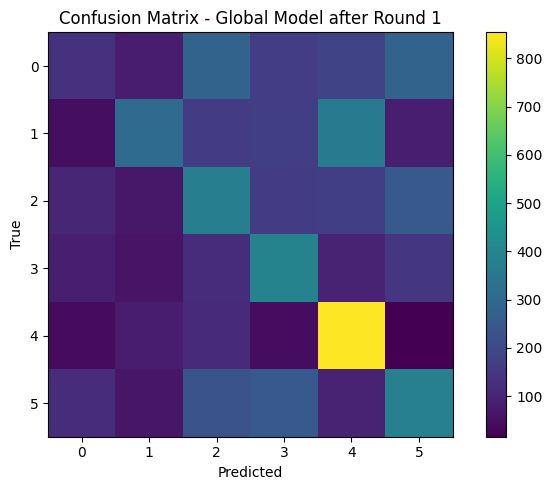


FEDERATED ROUND 2/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=37.3146, clip_scale=1.0000, DQA=1.8137, best_val_acc=0.4659

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=29.5392, clip_scale=1.0000, DQA=1.7656, best_val_acc=0.3937

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=26.9441, clip_scale=1.0000, DQA=1.7873, best_val_acc=0.4873

Client 4 (Hospital-D) streaming train samples: 922
Update norm=18.9896, clip_scale=1.0000, DQA=1.5225, best_val_acc=0.3436
\n======================================================================
Global Model after Round 2
accuracy            : 0.4389
balanced_accuracy   : 0.4409
precision_macro     : 0.4219
recall_macro        : 0.4409
f1_macro            : 0.4158
mcc                 : 0.3323
\nClassification report:
              precision    recall  f1-score   support

           0       0.35      0.24      0.28      1133
           1       0.45      0.40      0.43      1140
           2     

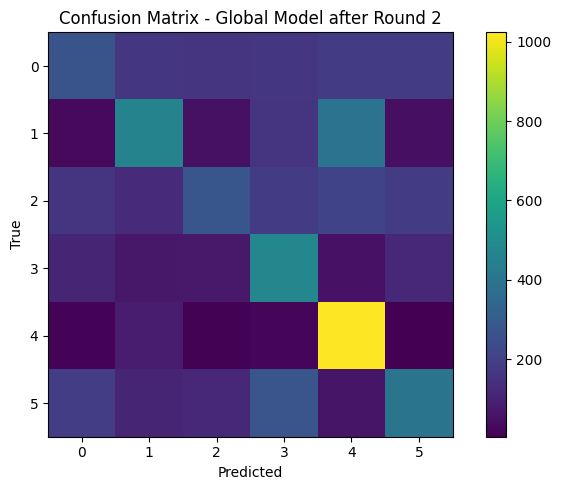


FEDERATED ROUND 3/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=59.4370, clip_scale=1.0000, DQA=1.7742, best_val_acc=0.5252

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=27.2793, clip_scale=1.0000, DQA=1.7743, best_val_acc=0.5089

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=24.6647, clip_scale=1.0000, DQA=1.9000, best_val_acc=0.5415

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=76.4876, clip_scale=1.0000, DQA=1.7114, best_val_acc=0.3967
\n======================================================================
Global Model after Round 3
accuracy            : 0.5170
balanced_accuracy   : 0.5168
precision_macro     : 0.5066
recall_macro        : 0.5168
f1_macro            : 0.5019
mcc                 : 0.4236
\nClassification report:
              precision    recall  f1-score   support

           0       0.46      0.28      0.34      1133
           1       0.56      0.56      0.56      1140
           2    

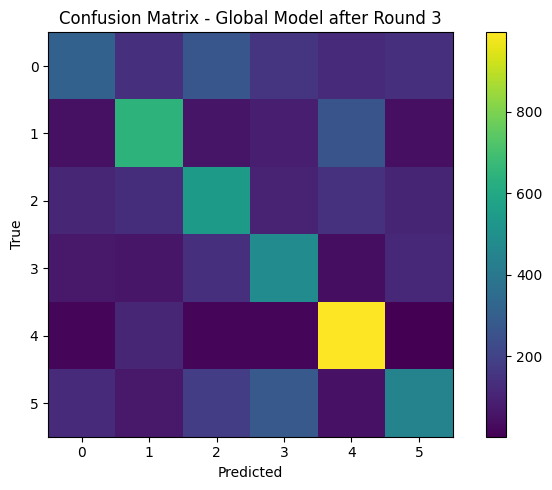


FEDERATED ROUND 4/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=27.3586, clip_scale=1.0000, DQA=1.9137, best_val_acc=0.5576

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=23.9375, clip_scale=1.0000, DQA=1.9864, best_val_acc=0.5531

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=21.9872, clip_scale=1.0000, DQA=2.0673, best_val_acc=0.5969

Client 4 (Hospital-D) streaming train samples: 922
Update norm=17.7775, clip_scale=1.0000, DQA=1.6686, best_val_acc=0.4233
\n======================================================================
Global Model after Round 4
accuracy            : 0.5767
balanced_accuracy   : 0.5794
precision_macro     : 0.5749
recall_macro        : 0.5794
f1_macro            : 0.5676
mcc                 : 0.4961
\nClassification report:
              precision    recall  f1-score   support

           0       0.49      0.38      0.43      1133
           1       0.67      0.55      0.61      1140
           2     

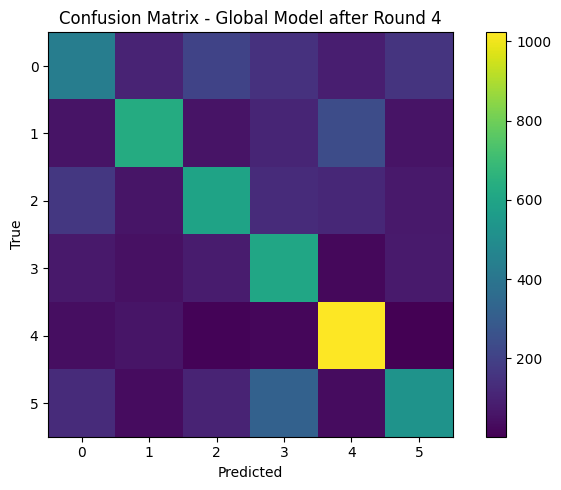


FEDERATED ROUND 5/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=35.8651, clip_scale=1.0000, DQA=2.3205, best_val_acc=0.6049

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=24.8581, clip_scale=1.0000, DQA=2.1253, best_val_acc=0.6000

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=21.7717, clip_scale=1.0000, DQA=2.1860, best_val_acc=0.6146

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=34.1405, clip_scale=1.0000, DQA=1.8698, best_val_acc=0.5561
\n======================================================================
Global Model after Round 5
accuracy            : 0.6266
balanced_accuracy   : 0.6274
precision_macro     : 0.6213
recall_macro        : 0.6274
f1_macro            : 0.6217
mcc                 : 0.5528
\nClassification report:
              precision    recall  f1-score   support

           0       0.55      0.46      0.50      1133
           1       0.68      0.64      0.66      1140
           2    

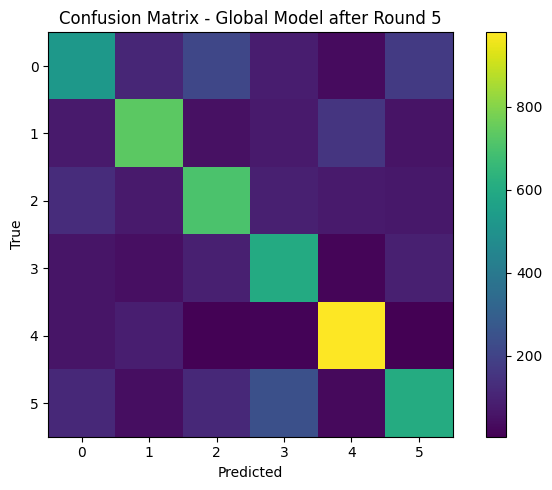


FEDERATED ROUND 6/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=16.8828, clip_scale=1.0000, DQA=2.2641, best_val_acc=0.6259

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=16.7179, clip_scale=1.0000, DQA=2.2807, best_val_acc=0.5966

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=19.9339, clip_scale=1.0000, DQA=2.4090, best_val_acc=0.6849

Client 4 (Hospital-D) streaming train samples: 922
Update norm=13.9117, clip_scale=1.0000, DQA=1.8362, best_val_acc=0.6258
\n======================================================================
Global Model after Round 6
accuracy            : 0.6570
balanced_accuracy   : 0.6580
precision_macro     : 0.6559
recall_macro        : 0.6580
f1_macro            : 0.6515
mcc                 : 0.5903
\nClassification report:
              precision    recall  f1-score   support

           0       0.58      0.52      0.55      1133
           1       0.75      0.62      0.68      1140
           2     

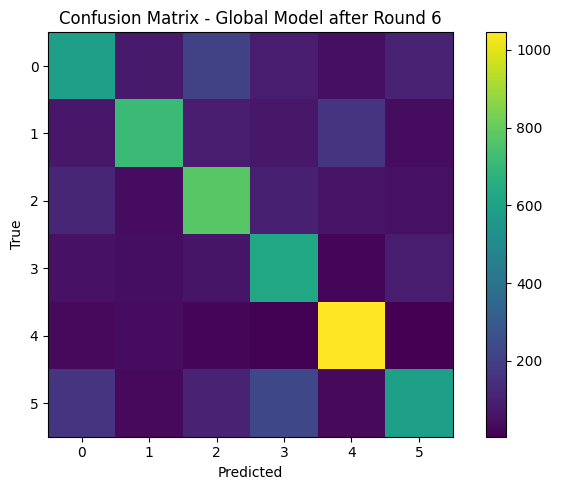


FEDERATED ROUND 7/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=29.1288, clip_scale=1.0000, DQA=2.1853, best_val_acc=0.7154

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=16.8090, clip_scale=1.0000, DQA=2.6171, best_val_acc=0.6260

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=22.2513, clip_scale=1.0000, DQA=2.6662, best_val_acc=0.7203

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=46.8162, clip_scale=1.0000, DQA=2.2194, best_val_acc=0.6163
\n======================================================================
Global Model after Round 7
accuracy            : 0.6943
balanced_accuracy   : 0.6942
precision_macro     : 0.6938
recall_macro        : 0.6942
f1_macro            : 0.6894
mcc                 : 0.6349
\nClassification report:
              precision    recall  f1-score   support

           0       0.65      0.53      0.58      1133
           1       0.75      0.69      0.72      1140
           2    

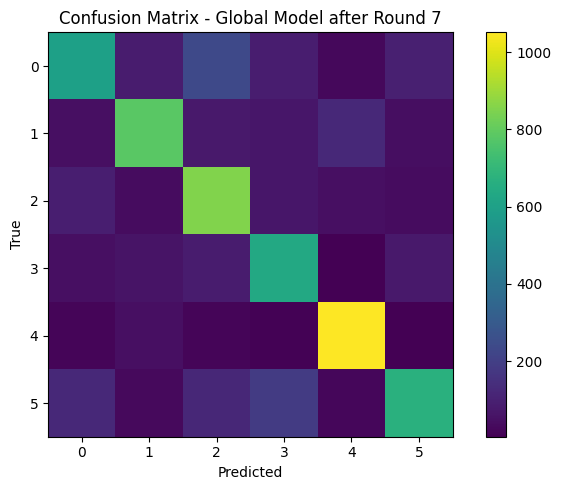


FEDERATED ROUND 8/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=27.6035, clip_scale=1.0000, DQA=2.3700, best_val_acc=0.6824

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=22.9177, clip_scale=1.0000, DQA=2.6083, best_val_acc=0.6546

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=23.4123, clip_scale=1.0000, DQA=2.7786, best_val_acc=0.7123

Client 4 (Hospital-D) streaming train samples: 922
Update norm=19.4290, clip_scale=1.0000, DQA=2.1507, best_val_acc=0.6319
\n======================================================================
Global Model after Round 8
accuracy            : 0.7362
balanced_accuracy   : 0.7347
precision_macro     : 0.7347
recall_macro        : 0.7347
f1_macro            : 0.7323
mcc                 : 0.6842
\nClassification report:
              precision    recall  f1-score   support

           0       0.69      0.64      0.66      1133
           1       0.77      0.74      0.75      1140
           2     

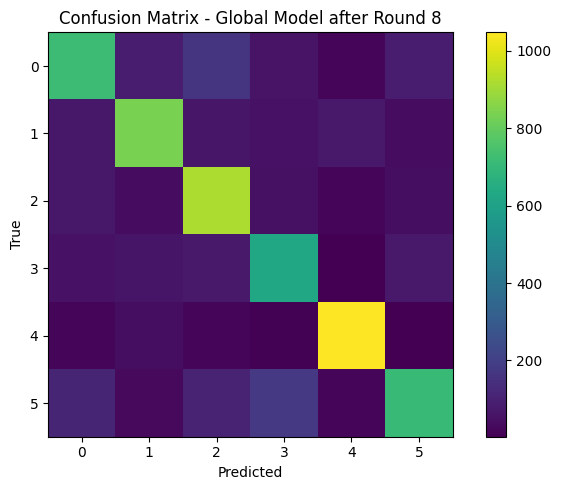


FEDERATED ROUND 9/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=24.8471, clip_scale=1.0000, DQA=2.5894, best_val_acc=0.7545

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=23.6439, clip_scale=1.0000, DQA=2.8942, best_val_acc=0.7317

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=20.2414, clip_scale=1.0000, DQA=2.8943, best_val_acc=0.7951

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=35.7864, clip_scale=1.0000, DQA=2.2566, best_val_acc=0.7106
\n======================================================================
Global Model after Round 9
accuracy            : 0.7546
balanced_accuracy   : 0.7546
precision_macro     : 0.7552
recall_macro        : 0.7546
f1_macro            : 0.7510
mcc                 : 0.7070
\nClassification report:
              precision    recall  f1-score   support

           0       0.74      0.64      0.69      1133
           1       0.80      0.77      0.78      1140
           2    

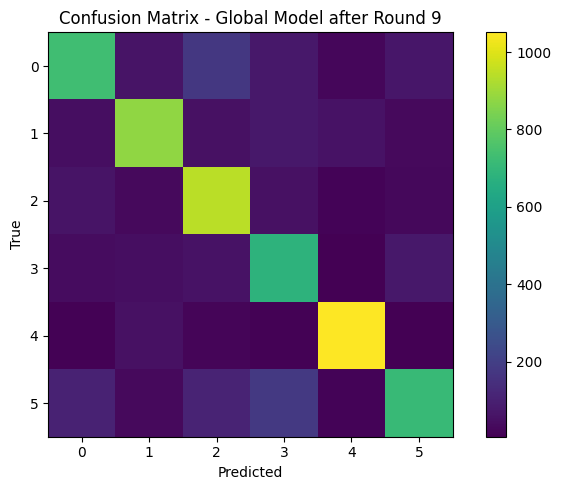


FEDERATED ROUND 10/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=27.0551, clip_scale=1.0000, DQA=2.9246, best_val_acc=0.7176

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=12.3414, clip_scale=1.0000, DQA=3.0597, best_val_acc=0.7295

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=17.2344, clip_scale=1.0000, DQA=3.2071, best_val_acc=0.8082

Client 4 (Hospital-D) streaming train samples: 922
Update norm=12.7730, clip_scale=1.0000, DQA=2.2097, best_val_acc=0.6687
\n======================================================================
Global Model after Round 10
accuracy            : 0.7692
balanced_accuracy   : 0.7674
precision_macro     : 0.7683
recall_macro        : 0.7674
f1_macro            : 0.7668
mcc                 : 0.7231
\nClassification report:
              precision    recall  f1-score   support

           0       0.67      0.69      0.68      1133
           1       0.83      0.75      0.79      1140
           2   

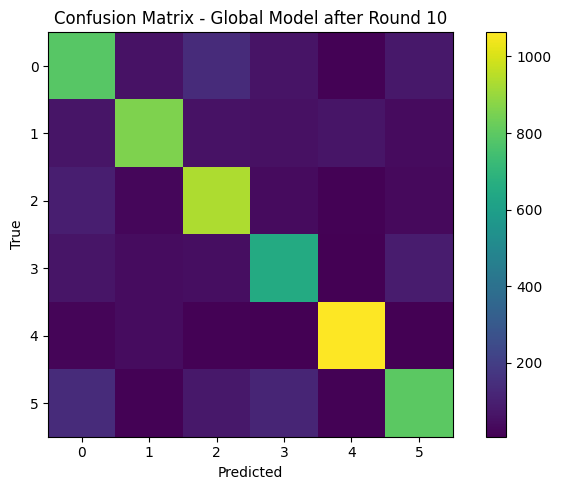


FEDERATED ROUND 11/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=30.3855, clip_scale=1.0000, DQA=2.9723, best_val_acc=0.7789

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=19.4106, clip_scale=1.0000, DQA=3.0480, best_val_acc=0.7610

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=18.3285, clip_scale=1.0000, DQA=3.3536, best_val_acc=0.8049

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=33.8740, clip_scale=1.0000, DQA=2.5031, best_val_acc=0.7138
\n======================================================================
Global Model after Round 11
accuracy            : 0.7946
balanced_accuracy   : 0.7928
precision_macro     : 0.7935
recall_macro        : 0.7928
f1_macro            : 0.7916
mcc                 : 0.7539
\nClassification report:
              precision    recall  f1-score   support

           0       0.76      0.70      0.73      1133
           1       0.83      0.79      0.81      1140
           2  

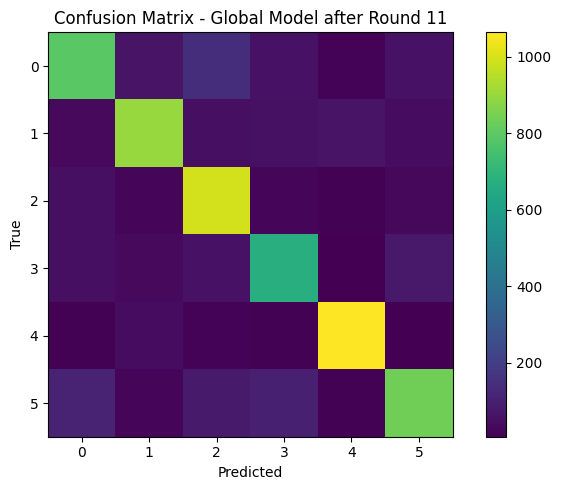


FEDERATED ROUND 12/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=22.1943, clip_scale=1.0000, DQA=3.0625, best_val_acc=0.7906

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=16.5636, clip_scale=1.0000, DQA=3.1012, best_val_acc=0.7947

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=22.4806, clip_scale=1.0000, DQA=3.4513, best_val_acc=0.8611

Client 4 (Hospital-D) streaming train samples: 922
Update norm=14.1033, clip_scale=1.0000, DQA=2.5724, best_val_acc=0.7117
\n======================================================================
Global Model after Round 12
accuracy            : 0.8062
balanced_accuracy   : 0.8051
precision_macro     : 0.8043
recall_macro        : 0.8051
f1_macro            : 0.8034
mcc                 : 0.7677
\nClassification report:
              precision    recall  f1-score   support

           0       0.75      0.73      0.74      1133
           1       0.84      0.83      0.83      1140
           2   

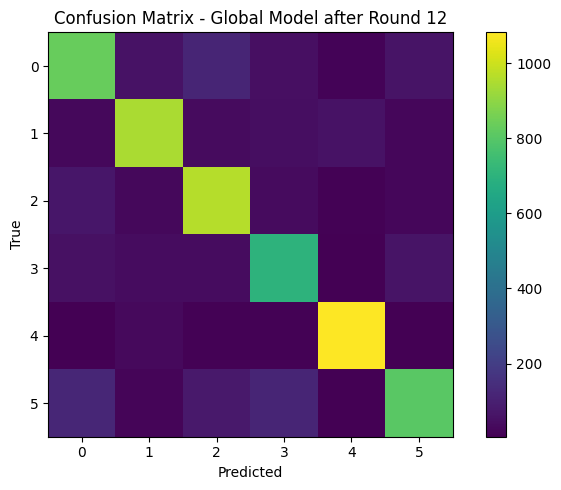


FEDERATED ROUND 13/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=21.4694, clip_scale=1.0000, DQA=3.9108, best_val_acc=0.8000

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=22.5915, clip_scale=1.0000, DQA=3.3678, best_val_acc=0.8390

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=13.7706, clip_scale=1.0000, DQA=3.9787, best_val_acc=0.8423

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=28.8676, clip_scale=1.0000, DQA=2.6385, best_val_acc=0.7951
\n======================================================================
Global Model after Round 13
accuracy            : 0.8222
balanced_accuracy   : 0.8216
precision_macro     : 0.8200
recall_macro        : 0.8216
f1_macro            : 0.8198
mcc                 : 0.7869
\nClassification report:
              precision    recall  f1-score   support

           0       0.82      0.72      0.77      1133
           1       0.85      0.83      0.84      1140
           2  

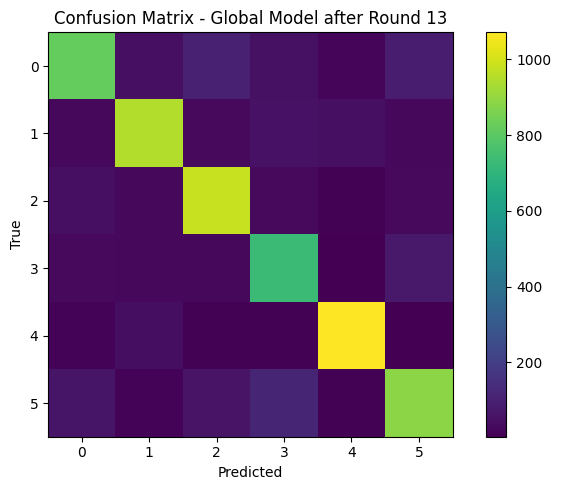


FEDERATED ROUND 14/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=24.7439, clip_scale=1.0000, DQA=3.4399, best_val_acc=0.8259

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=19.1933, clip_scale=1.0000, DQA=3.4774, best_val_acc=0.8309

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=12.7303, clip_scale=1.0000, DQA=4.0302, best_val_acc=0.8493

Client 4 (Hospital-D) streaming train samples: 922
Update norm=14.2185, clip_scale=1.0000, DQA=2.7636, best_val_acc=0.7791
\n======================================================================
Global Model after Round 14
accuracy            : 0.8302
balanced_accuracy   : 0.8281
precision_macro     : 0.8287
recall_macro        : 0.8281
f1_macro            : 0.8276
mcc                 : 0.7964
\nClassification report:
              precision    recall  f1-score   support

           0       0.81      0.77      0.79      1133
           1       0.86      0.84      0.85      1140
           2   

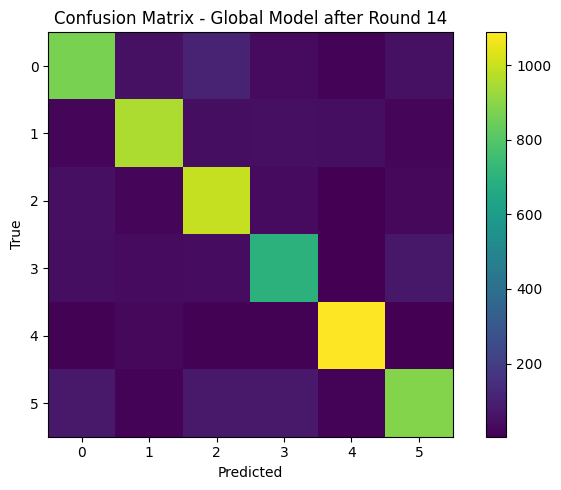


FEDERATED ROUND 15/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=11.5800, clip_scale=1.0000, DQA=3.5650, best_val_acc=0.8260

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=23.0446, clip_scale=1.0000, DQA=3.7505, best_val_acc=0.8797

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=18.6289, clip_scale=1.0000, DQA=4.0155, best_val_acc=0.8602

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=44.7157, clip_scale=1.0000, DQA=2.8130, best_val_acc=0.7317
\n======================================================================
Global Model after Round 15
accuracy            : 0.8392
balanced_accuracy   : 0.8390
precision_macro     : 0.8384
recall_macro        : 0.8390
f1_macro            : 0.8371
mcc                 : 0.8075
\nClassification report:
              precision    recall  f1-score   support

           0       0.84      0.76      0.80      1133
           1       0.87      0.85      0.86      1140
           2  

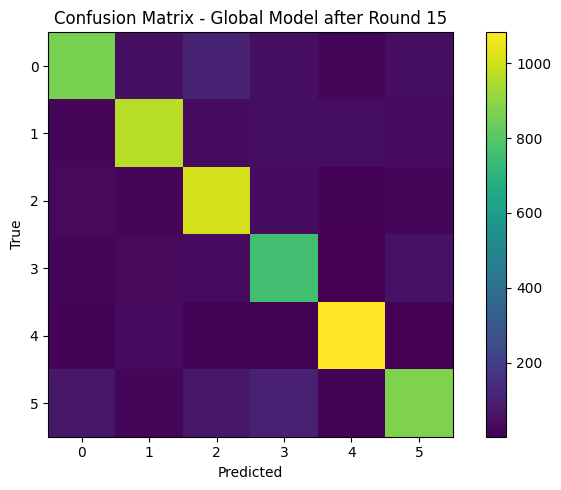


FEDERATED ROUND 16/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=22.1123, clip_scale=1.0000, DQA=3.4607, best_val_acc=0.8141

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=13.5434, clip_scale=1.0000, DQA=3.7758, best_val_acc=0.8406

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=8.8012, clip_scale=1.0000, DQA=4.2876, best_val_acc=0.8767

Client 4 (Hospital-D) streaming train samples: 922
Update norm=9.4240, clip_scale=1.0000, DQA=2.8854, best_val_acc=0.8098
\n======================================================================
Global Model after Round 16
accuracy            : 0.8423
balanced_accuracy   : 0.8406
precision_macro     : 0.8408
recall_macro        : 0.8406
f1_macro            : 0.8398
mcc                 : 0.8109
\nClassification report:
              precision    recall  f1-score   support

           0       0.81      0.78      0.79      1133
           1       0.87      0.84      0.86      1140
           2     

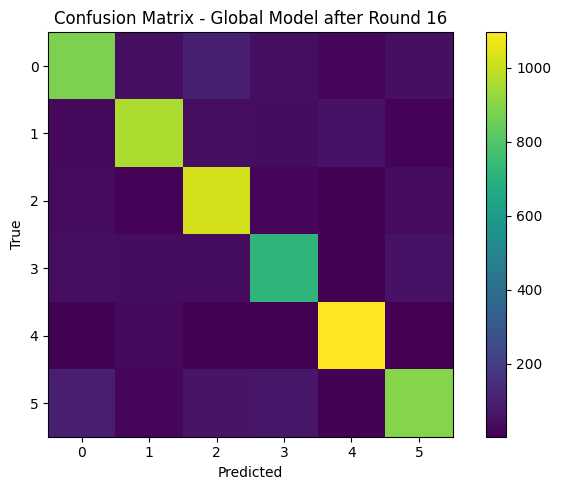


FEDERATED ROUND 17/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=27.3946, clip_scale=1.0000, DQA=3.5084, best_val_acc=0.8439

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=23.4843, clip_scale=1.0000, DQA=4.0294, best_val_acc=0.8488

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=8.9044, clip_scale=1.0000, DQA=4.2671, best_val_acc=0.8797

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=33.0086, clip_scale=1.0000, DQA=3.0200, best_val_acc=0.8504
\n======================================================================
Global Model after Round 17
accuracy            : 0.8558
balanced_accuracy   : 0.8533
precision_macro     : 0.8546
recall_macro        : 0.8533
f1_macro            : 0.8536
mcc                 : 0.8268
\nClassification report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1133
           1       0.87      0.87      0.87      1140
           2   

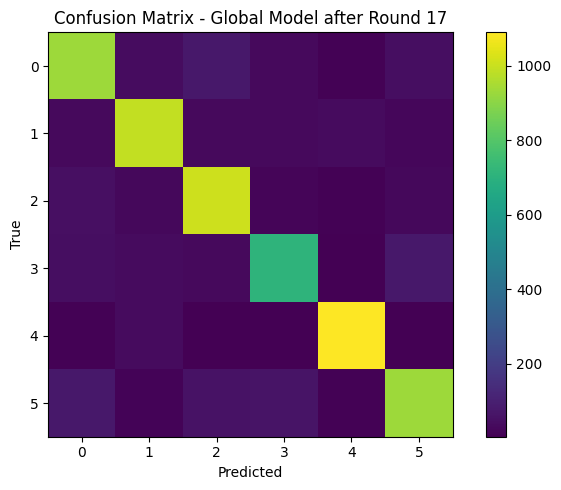


FEDERATED ROUND 18/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=23.2711, clip_scale=1.0000, DQA=3.8851, best_val_acc=0.8565

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=12.4038, clip_scale=1.0000, DQA=3.9222, best_val_acc=0.8551

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=19.7567, clip_scale=1.0000, DQA=4.3452, best_val_acc=0.8865

Client 4 (Hospital-D) streaming train samples: 922
Update norm=17.4800, clip_scale=1.0000, DQA=3.0902, best_val_acc=0.8160
\n======================================================================
Global Model after Round 18
accuracy            : 0.8627
balanced_accuracy   : 0.8603
precision_macro     : 0.8619
recall_macro        : 0.8603
f1_macro            : 0.8605
mcc                 : 0.8352
\nClassification report:
              precision    recall  f1-score   support

           0       0.85      0.80      0.82      1133
           1       0.88      0.86      0.87      1140
           2   

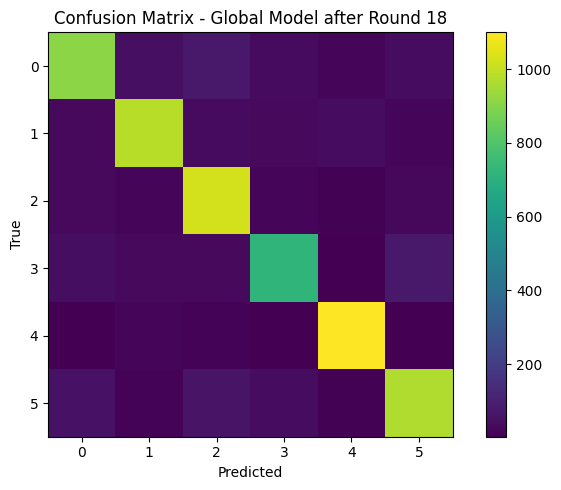


FEDERATED ROUND 19/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=27.4259, clip_scale=1.0000, DQA=3.9784, best_val_acc=0.8699

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=21.2764, clip_scale=1.0000, DQA=4.3208, best_val_acc=0.8894

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=12.1328, clip_scale=1.0000, DQA=4.8379, best_val_acc=0.8780

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=31.4968, clip_scale=1.0000, DQA=3.2620, best_val_acc=0.8276
\n======================================================================
Global Model after Round 19
accuracy            : 0.8618
balanced_accuracy   : 0.8595
precision_macro     : 0.8613
recall_macro        : 0.8595
f1_macro            : 0.8600
mcc                 : 0.8341
\nClassification report:
              precision    recall  f1-score   support

           0       0.84      0.81      0.83      1133
           1       0.86      0.88      0.87      1140
           2  

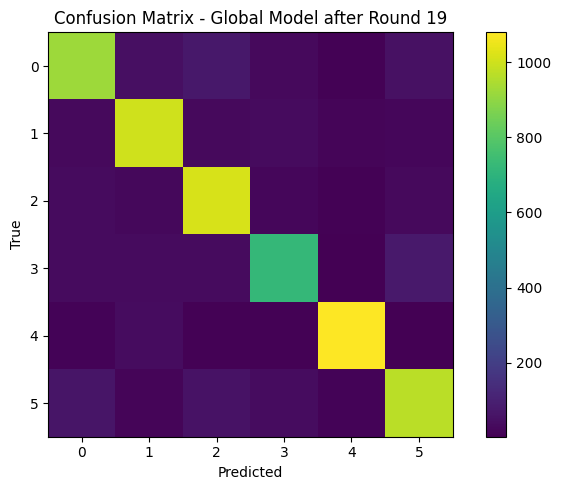


FEDERATED ROUND 20/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=18.6134, clip_scale=1.0000, DQA=4.0837, best_val_acc=0.8729

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=18.5010, clip_scale=1.0000, DQA=4.0605, best_val_acc=0.8744

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=13.4666, clip_scale=1.0000, DQA=4.7488, best_val_acc=0.9002

Client 4 (Hospital-D) streaming train samples: 922
Update norm=12.1651, clip_scale=1.0000, DQA=3.0992, best_val_acc=0.8773
\n======================================================================
Global Model after Round 20
accuracy            : 0.8691
balanced_accuracy   : 0.8673
precision_macro     : 0.8681
recall_macro        : 0.8673
f1_macro            : 0.8670
mcc                 : 0.8430
\nClassification report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1133
           1       0.86      0.89      0.88      1140
           2   

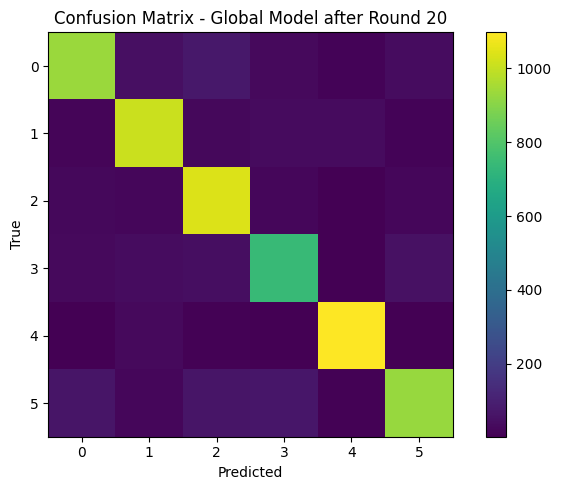


FEDERATED ROUND 21/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=24.3429, clip_scale=1.0000, DQA=4.2456, best_val_acc=0.8846

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=17.7732, clip_scale=1.0000, DQA=3.8803, best_val_acc=0.8455

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=19.8845, clip_scale=1.0000, DQA=4.7364, best_val_acc=0.8976

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=35.3259, clip_scale=1.0000, DQA=3.6940, best_val_acc=0.8455
\n======================================================================
Global Model after Round 21
accuracy            : 0.8810
balanced_accuracy   : 0.8789
precision_macro     : 0.8814
recall_macro        : 0.8789
f1_macro            : 0.8793
mcc                 : 0.8574
\nClassification report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1133
           1       0.90      0.89      0.89      1140
           2  

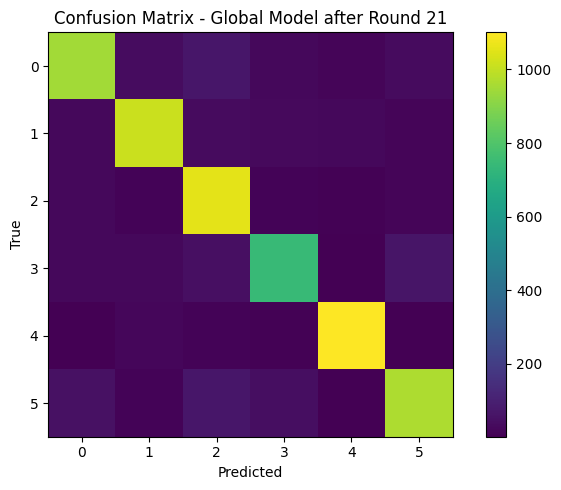


FEDERATED ROUND 22/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=13.4249, clip_scale=1.0000, DQA=4.3252, best_val_acc=0.8941

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=8.7952, clip_scale=1.0000, DQA=4.8040, best_val_acc=0.9130

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=21.0843, clip_scale=1.0000, DQA=5.2436, best_val_acc=0.9061

Client 4 (Hospital-D) streaming train samples: 922
Update norm=15.9676, clip_scale=1.0000, DQA=3.0780, best_val_acc=0.8650
\n======================================================================
Global Model after Round 22
accuracy            : 0.8789
balanced_accuracy   : 0.8779
precision_macro     : 0.8775
recall_macro        : 0.8779
f1_macro            : 0.8769
mcc                 : 0.8549
\nClassification report:
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      1133
           1       0.90      0.88      0.89      1140
           2    

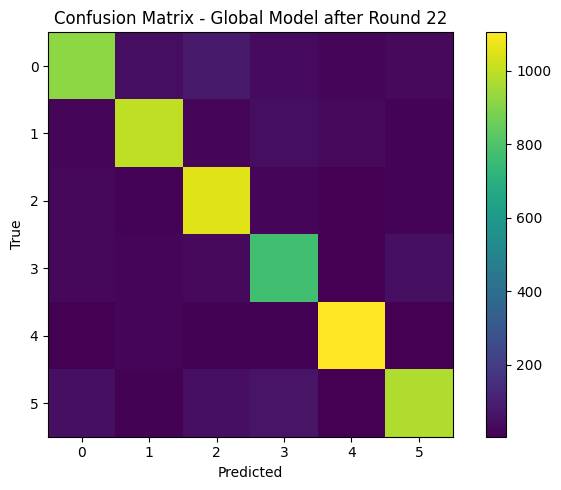


FEDERATED ROUND 23/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=18.1611, clip_scale=1.0000, DQA=4.7879, best_val_acc=0.8878

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=10.9825, clip_scale=1.0000, DQA=4.4256, best_val_acc=0.8829

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=17.3874, clip_scale=1.0000, DQA=5.3568, best_val_acc=0.9171

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=42.6470, clip_scale=1.0000, DQA=3.7777, best_val_acc=0.8862
\n======================================================================
Global Model after Round 23
accuracy            : 0.8868
balanced_accuracy   : 0.8847
precision_macro     : 0.8849
recall_macro        : 0.8847
f1_macro            : 0.8845
mcc                 : 0.8640
\nClassification report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1133
           1       0.89      0.91      0.90      1140
           2  

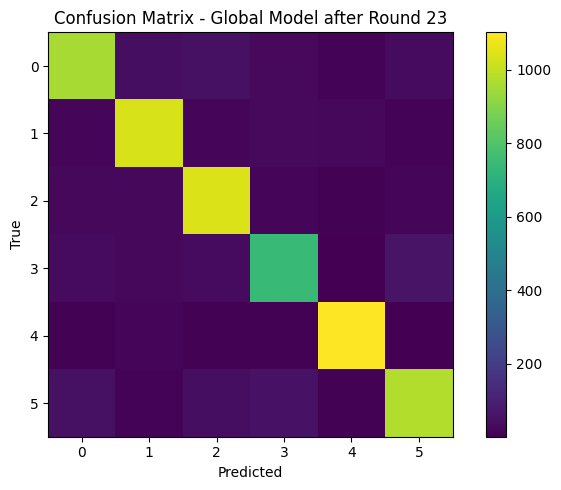


FEDERATED ROUND 24/25

Client 1 (Hospital-A) streaming train samples: 2404
Update norm=24.0414, clip_scale=1.0000, DQA=4.3691, best_val_acc=0.9129

Client 2 (Hospital-B) streaming train samples: 2343
Update norm=17.9001, clip_scale=1.0000, DQA=4.5039, best_val_acc=0.8913

Client 3 (Hospital-C) streaming train samples: 2892
Update norm=8.0476, clip_scale=1.0000, DQA=5.0348, best_val_acc=0.9100

Client 4 (Hospital-D) streaming train samples: 922
Update norm=18.5682, clip_scale=1.0000, DQA=4.1191, best_val_acc=0.8834
\n======================================================================
Global Model after Round 24
accuracy            : 0.8919
balanced_accuracy   : 0.8908
precision_macro     : 0.8903
recall_macro        : 0.8908
f1_macro            : 0.8903
mcc                 : 0.8703
\nClassification report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.87      1133
           1       0.90      0.89      0.90      1140
           2    

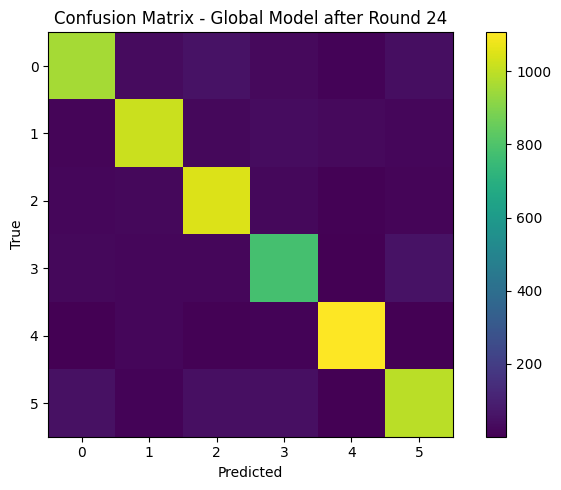


FEDERATED ROUND 25/25

Client 1 (Hospital-A) streaming train samples: 3481
Update norm=12.1301, clip_scale=1.0000, DQA=4.4460, best_val_acc=0.9057

Client 2 (Hospital-B) streaming train samples: 3481
Update norm=25.5192, clip_scale=1.0000, DQA=5.2004, best_val_acc=0.9008

Client 3 (Hospital-C) streaming train samples: 3481
Update norm=19.4871, clip_scale=1.0000, DQA=5.1418, best_val_acc=0.9154

Client 4 (Hospital-D) streaming train samples: 3481
Update norm=29.8225, clip_scale=1.0000, DQA=3.8192, best_val_acc=0.8732
\n======================================================================
Global Model after Round 25
accuracy            : 0.8934
balanced_accuracy   : 0.8909
precision_macro     : 0.8932
recall_macro        : 0.8909
f1_macro            : 0.8916
mcc                 : 0.8721
\nClassification report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.87      1133
           1       0.90      0.89      0.90      1140
           2  

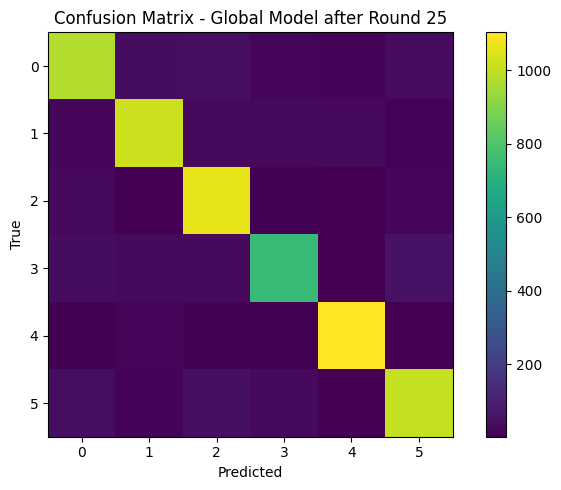

,round,client,samples,epochs,lr,raw_update_norm,clip_scale,dqa,best_val_accuracy,final_loss,final_val_loss,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,mcc,epsilon_estimate,round_time_seconds
95,24,Hospital-D,922,5,0.0012,18.568214,1.0,4.119144,0.883436,0.302498,0.530506,0.891912,0.890832,0.890311,0.890832,0.890294,0.870258,235078.800048,75.403901
96,25,Hospital-A,3481,6,0.0010,12.130064,1.0,4.445951,0.905691,0.347076,0.555192,0.893424,0.890886,0.893215,0.890886,0.891604,0.872050,239926.295609,102.696574
97,25,Hospital-B,3481,5,0.0008,25.519236,1.0,5.200367,0.900813,0.344003,0.447352,0.893424,0.890886,0.893215,0.890886,0.891604,0.872050,239926.295609,102.696574
98,25,Hospital-C,3481,6,0.0006,19.487053,1.0,5.141785,0.915447,0.270870,0.424765,0.893424,0.890886,0.893215,0.890886,0.891604,0.872050,239926.295609,102.696574
99,25,Hospital-D,3481,5,0.0012,29.822489,1.0,3.819246,0.873171,0.384506,0.612291,0.893424,0.890886,0.893215,0.890886,0.891604,0.872050,239926.295609,102.696574


Saved high-accuracy FL logs and global model to /kaggle/working


In [8]:
round_logs = []
global_weights = global_model.get_weights()

# Persistent streaming pointers: each client moves through its ECG stream across rounds.
client_stream_positions = [0 for _ in range(NUM_CLIENTS)]

for rnd in range(1, FED_ROUNDS + 1):
    print("\n" + "="*80)
    print(f"FEDERATED ROUND {rnd}/{FED_ROUNDS}")
    print("="*80)

    participating_updates = []
    participating_counts = []
    client_logs = []

    round_start = time.time()

    for cid, (cx, cy) in enumerate(client_datasets):
        cfg = CLIENT_CONFIGS[cid]

        # Real-time component: receive the next ECG streaming window.
        start = client_stream_positions[cid]
        end = start + STREAM_CHUNK_SIZE

        if start >= len(cx):
            # When the local stream ends, reshuffle and continue.
            idx = np.arange(len(cx))
            np.random.shuffle(idx)
            cx, cy = cx[idx], cy[idx]
            client_datasets[cid] = (cx, cy)
            start = 0
            end = STREAM_CHUNK_SIZE

        X_stream = cx[start:min(end, len(cx))]
        y_stream = cy[start:min(end, len(cy))]
        client_stream_positions[cid] = end

        if len(X_stream) < 40:
            print(f"Skipping client {cid+1}; not enough streaming samples.")
            continue

        # Safe stratified split.
        stratify_labels = np.argmax(y_stream, axis=1)
        unique_classes, class_counts = np.unique(stratify_labels, return_counts=True)
        can_stratify = (
            len(unique_classes) > 1
            and len(X_stream) >= 40
            and np.min(class_counts) >= 2
        )

        if can_stratify:
            X_local, X_val, y_local, y_val = train_test_split(
                X_stream,
                y_stream,
                test_size=0.15,
                random_state=SEED + rnd + cid,
                stratify=stratify_labels
            )
        else:
            X_local, X_val, y_local, y_val = train_test_split(
                X_stream,
                y_stream,
                test_size=0.15,
                random_state=SEED + rnd + cid,
                shuffle=True
            )

        print(f"\nClient {cid+1} ({cfg['name']}) streaming train samples: {len(X_local)}")
        time.sleep(cfg["latency"])

        local_model = clone_compiled_model(global_model, lr=cfg["lr"])
        old_weights = local_model.get_weights()

        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_accuracy",
                patience=4,
                restore_best_weights=True,
                mode="max",
                min_delta=1e-4
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=2,
                min_lr=1e-5
            )
        ]

        class_weight = compute_balanced_class_weight(y_local)

        history = local_model.fit(
            X_local, y_local,
            validation_data=(X_val, y_val),
            epochs=cfg["epochs"],
            batch_size=LOCAL_BATCH_SIZE,
            callbacks=callbacks,
            class_weight=class_weight,
            verbose=0
        )

        new_weights = local_model.get_weights()
        raw_update = get_update(new_weights, old_weights)

        clipped_update, raw_norm, clip_scale = clip_weights_update(raw_update, clip_norm=CLIP_NORM)
        private_update = add_gaussian_noise(
            clipped_update,
            noise_multiplier=NOISE_MULTIPLIER,
            clip_norm=CLIP_NORM
        )

        dqa = client_data_quality_score(history, y_local)

        participating_updates.append(private_update)
        participating_counts.append(len(X_local))

        best_val_acc = float(np.max(history.history.get("val_accuracy", [0])))
        client_logs.append({
            "round": rnd,
            "client": cfg["name"],
            "samples": len(X_local),
            "epochs": cfg["epochs"],
            "lr": cfg["lr"],
            "raw_update_norm": raw_norm,
            "clip_scale": clip_scale,
            "dqa": dqa,
            "best_val_accuracy": best_val_acc,
            "final_loss": history.history["loss"][-1],
            "final_val_loss": history.history.get("val_loss", [np.nan])[-1],
        })

        print(
            f"Update norm={raw_norm:.4f}, clip_scale={clip_scale:.4f}, "
            f"DQA={dqa:.4f}, best_val_acc={best_val_acc:.4f}"
        )

    # Secure aggregation simulation
    if participating_updates:
        agg_update = secure_aggregate_simulated(participating_updates, participating_counts)
        global_weights = apply_update(global_weights, agg_update)
        global_model.set_weights(global_weights)

    round_time = time.time() - round_start
    metrics = evaluate_model(
        global_model,
        X_global_test,
        y_global_test,
        title=f"Global Model after Round {rnd}",
        plot_roc=False
    )
    eps = estimate_epsilon(rnd, NOISE_MULTIPLIER, delta=DELTA)

    for log in client_logs:
        log.update(metrics)
        log["epsilon_estimate"] = eps
        log["round_time_seconds"] = round_time
        round_logs.append(log)

results_df = pd.DataFrame(round_logs)
display(results_df.tail())
results_df.to_csv("/kaggle/working/pp_hfl_realtime_round_logs_high_accuracy.csv", index=False)
global_model.save("/kaggle/working/pp_hfl_realtime_global_model_high_accuracy.keras")
print("Saved high-accuracy FL logs and global model to /kaggle/working")

## Final Evaluation and Plots

\n======================================================================
Final Global PP-HFL Model before Personalization
accuracy            : 0.8934
balanced_accuracy   : 0.8909
precision_macro     : 0.8932
recall_macro        : 0.8909
f1_macro            : 0.8916
mcc                 : 0.8721
\nClassification report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.87      1133
           1       0.90      0.89      0.90      1140
           2       0.86      0.94      0.90      1135
           3       0.89      0.82      0.85       903
           4       0.95      0.96      0.95      1153
           5       0.89      0.87      0.88      1151

    accuracy                           0.89      6615
   macro avg       0.89      0.89      0.89      6615
weighted avg       0.89      0.89      0.89      6615



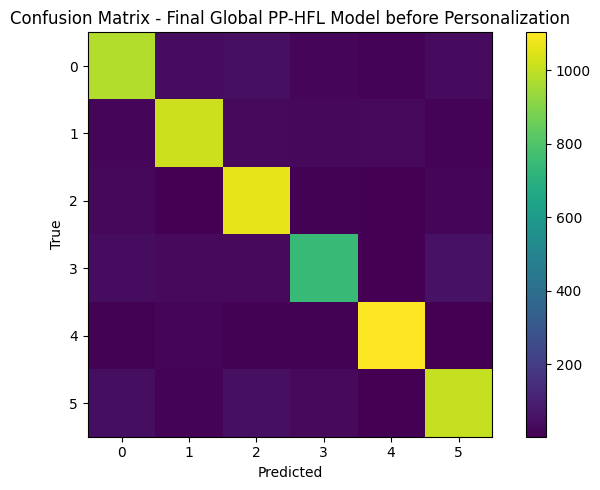

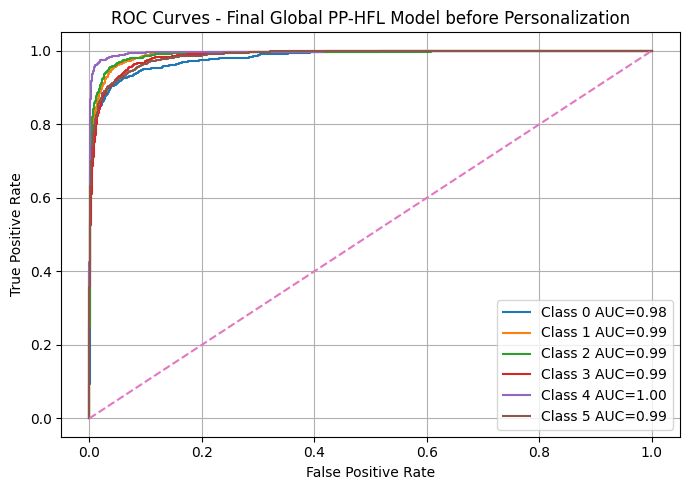


PERSONALIZATION / FINE-TUNING STAGE
Epoch 1/8
703/703 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - accuracy: 0.9024 - auc: 0.9902 - loss: 0.4431 - precision: 0.9236 - recall: 0.8856 - val_accuracy: 0.9463 - val_auc: 0.9975 - val_loss: 0.3094 - val_precision: 0.9619 - val_recall: 0.9340 - learning_rate: 2.0000e-04
Epoch 2/8
703/703 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.9166 - auc: 0.9924 - loss: 0.4040 - precision: 0.9349 - recall: 0.9022 - val_accuracy: 0.9473 - val_auc: 0.9974 - val_loss: 0.3058 - val_precision: 0.9580 - val_recall: 0.9368 - learning_rate: 2.0000e-04
Epoch 3/8
703/703 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.9241 - auc: 0.9939 - loss: 0.3762 - precision: 0.9406 - recall: 0.9112 - val_accuracy: 0.9408 - val_auc: 0.9968 - val_loss: 0.3203 - val_precision: 0.9556 - val_recall: 0.9320 - learning_rate: 2.0000e-04
Epoch 4/8
703/703 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.9313 - auc: 0.9951 - loss: 0.3529 - precision: 0.9466 - recall: 0.9195 - val_accura

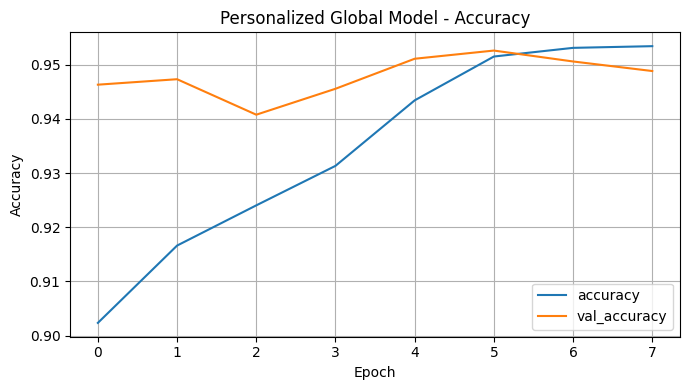

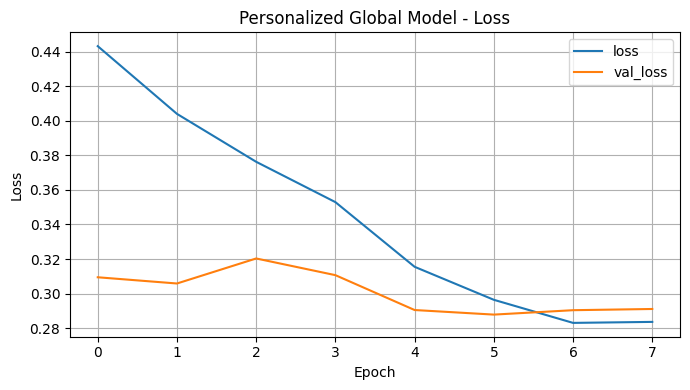

\n======================================================================
Personalized PP-HFL Model Final Test
accuracy            : 0.9273
balanced_accuracy   : 0.9252
precision_macro     : 0.9266
recall_macro        : 0.9252
f1_macro            : 0.9256
mcc                 : 0.9127
\nClassification report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92      1133
           1       0.90      0.93      0.92      1140
           2       0.90      0.96      0.93      1135
           3       0.90      0.87      0.88       903
           4       0.97      0.96      0.97      1153
           5       0.94      0.92      0.93      1151

    accuracy                           0.93      6615
   macro avg       0.93      0.93      0.93      6615
weighted avg       0.93      0.93      0.93      6615



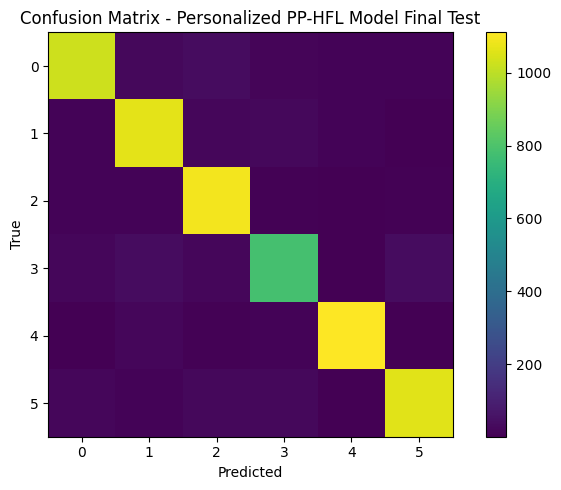

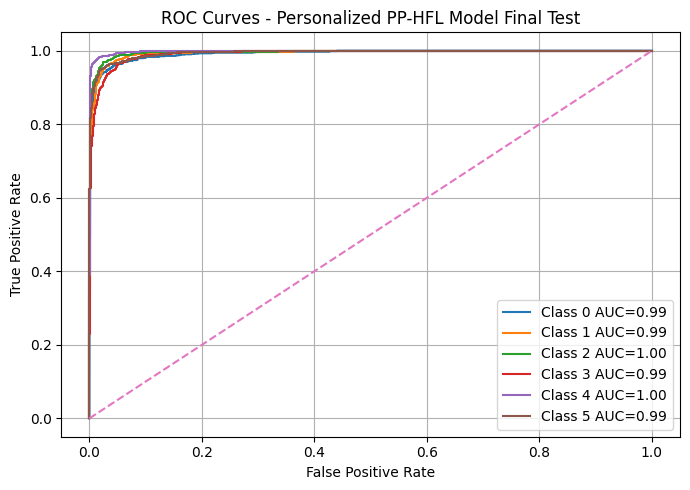

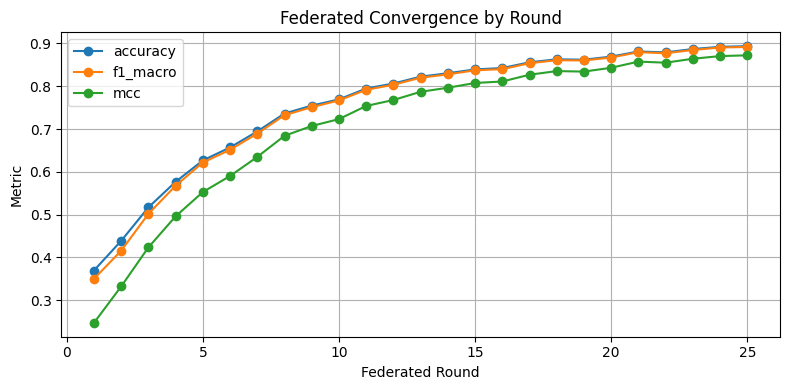

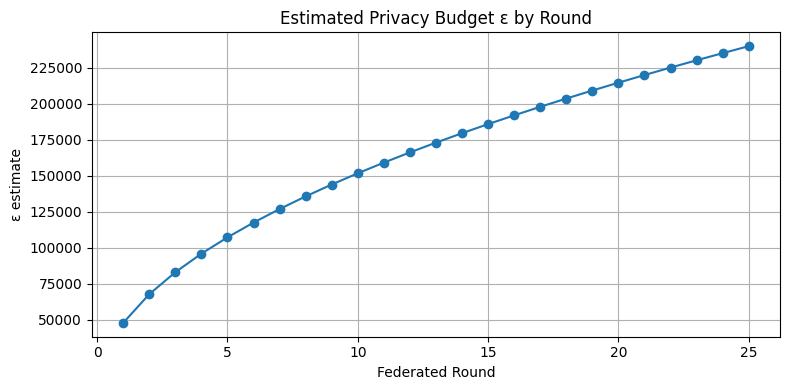

<Figure size 800x400 with 0 Axes>

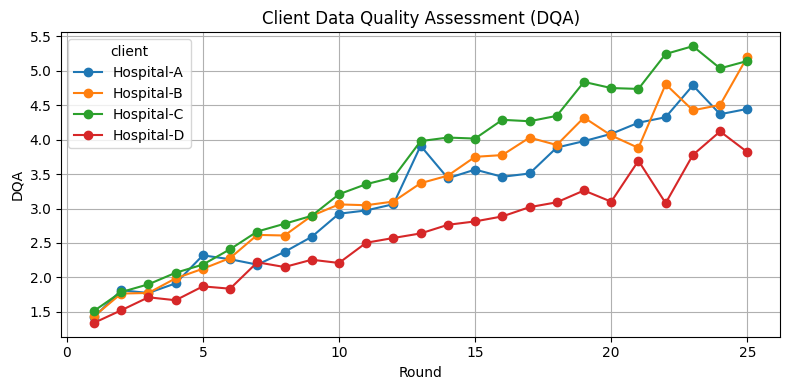

All result files saved to /kaggle/working


In [9]:
# ============================================================
# Final evaluation before personalization
# ============================================================

final_results = evaluate_model(
    global_model,
    X_global_test,
    y_global_test,
    title="Final Global PP-HFL Model before Personalization",
    plot_roc=True
)
pd.DataFrame([final_results]).to_csv("/kaggle/working/pp_hfl_final_global_results_high_accuracy.csv", index=False)

# ============================================================
# Optional personalization / fine-tuning
# ============================================================
# This keeps the federated global model, then performs a short local adaptation.
# In real FL healthcare systems this is common because each hospital can personalize
# the global model to its local ECG distribution.
# For your dissertation, report both:
# 1. Global FL accuracy
# 2. Personalized FL accuracy

if ENABLE_FINAL_PERSONALIZATION:
    print("\n" + "="*80)
    print("PERSONALIZATION / FINE-TUNING STAGE")
    print("="*80)

    personalized_model = clone_compiled_model(global_model, lr=2e-4)

    # Use all federated training data for final local adaptation simulation.
    # This is not central training from scratch; it starts from the federated global model.
    X_personal = np.concatenate([c[0] for c in client_datasets], axis=0)
    y_personal = np.concatenate([c[1] for c in client_datasets], axis=0)

    X_p_train, X_p_val, y_p_train, y_p_val = train_test_split(
        X_personal,
        y_personal,
        test_size=0.15,
        random_state=SEED,
        stratify=np.argmax(y_personal, axis=1)
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=5,
            restore_best_weights=True,
            mode="max"
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6
        )
    ]

    class_weight = compute_balanced_class_weight(y_p_train)

    personalization_history = personalized_model.fit(
        X_p_train,
        y_p_train,
        validation_data=(X_p_val, y_p_val),
        epochs=PERSONALIZATION_EPOCHS,
        batch_size=32,
        callbacks=callbacks,
        class_weight=class_weight,
        verbose=1
    )

    plot_history(personalization_history, title="Personalized Global Model")

    personalized_results = evaluate_model(
        personalized_model,
        X_global_test,
        y_global_test,
        title="Personalized PP-HFL Model Final Test",
        plot_roc=True
    )

    pd.DataFrame([personalized_results]).to_csv(
        "/kaggle/working/pp_hfl_personalized_results_high_accuracy.csv",
        index=False
    )
    personalized_model.save("/kaggle/working/pp_hfl_personalized_model_high_accuracy.keras")

# ============================================================
# Training curves and report plots
# ============================================================

plt.figure(figsize=(8,4))
round_summary = results_df.groupby("round")[["accuracy", "f1_macro", "mcc"]].mean()
for col in round_summary.columns:
    plt.plot(round_summary.index, round_summary[col], marker="o", label=col)
plt.title("Federated Convergence by Round")
plt.xlabel("Federated Round")
plt.ylabel("Metric")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
eps_by_round = results_df.groupby("round")["epsilon_estimate"].mean()
plt.plot(eps_by_round.index, eps_by_round.values, marker="o")
plt.title("Estimated Privacy Budget ε by Round")
plt.xlabel("Federated Round")
plt.ylabel("ε estimate")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
dqa = results_df.groupby(["round", "client"])["dqa"].mean().unstack()
dqa.plot(marker="o", figsize=(8,4))
plt.title("Client Data Quality Assessment (DQA)")
plt.xlabel("Round")
plt.ylabel("DQA")
plt.grid(True)
plt.tight_layout()
plt.show()

print("All result files saved to /kaggle/working")

## Supervisor Requirement 2 — Comparative Experiments

To demonstrate the effectiveness of the proposed method, this section compares the proposed PP-HFL model against representative baselines commonly used in federated learning studies.

| Method | What it Represents | Why it is Included |
|---|---|---|
| Centralized CNN–BiLSTM | Traditional training with all data in one place | Upper-bound style baseline, but less privacy-preserving |
| Local-only learning | Each hospital trains independently | Shows what happens without collaboration |
| FedAvg | Standard federated averaging baseline | Most common FL baseline |
| DP-FedAvg | FedAvg with clipping and Gaussian noise | Privacy-preserving FL baseline |
| FedProx-style FL | FL with proximal damping to reduce client drift | Representative heterogeneous FL baseline |
| Proposed PP-HFL | Real-time + heterogeneous + privacy-preserving + secure aggregation + personalization | Main dissertation contribution |

**Important:** These experiments may take time on Kaggle. If runtime is too long, reduce `COMPARISON_ROUNDS` or set `RUN_COMPARATIVE_EXPERIMENTS = False` after generating the first table.


Running Centralized CNN-BiLSTM baseline...
Epoch 1/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - accuracy: 0.3373 - auc: 0.7136 - loss: 1.7057 - precision: 0.5859 - recall: 0.0732 - val_accuracy: 0.4109 - val_auc: 0.7841 - val_loss: 1.5357 - val_precision: 0.7136 - val_recall: 0.1162 - learning_rate: 0.0010
Epoch 2/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.4317 - auc: 0.7950 - loss: 1.5004 - precision: 0.6490 - recall: 0.1717 - val_accuracy: 0.4855 - val_auc: 0.8357 - val_loss: 1.3740 - val_precision: 0.7336 - val_recall: 0.2192 - learning_rate: 0.0010
Epoch 3/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.5046 - auc: 0.8406 - loss: 1.3603 - precision: 0.6725 - recall: 0.2802 - val_accuracy: 0.5384 - val_auc: 0.8664 - val_loss: 1.2675 - val_precision: 0.6699 - val_recall: 0.3666 - learning_rate: 0.0010
Epoch 4/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.5691 - auc: 0.8765 - loss: 1.2351 - precision: 0.7036 - recall: 0.3937 - val_accurac

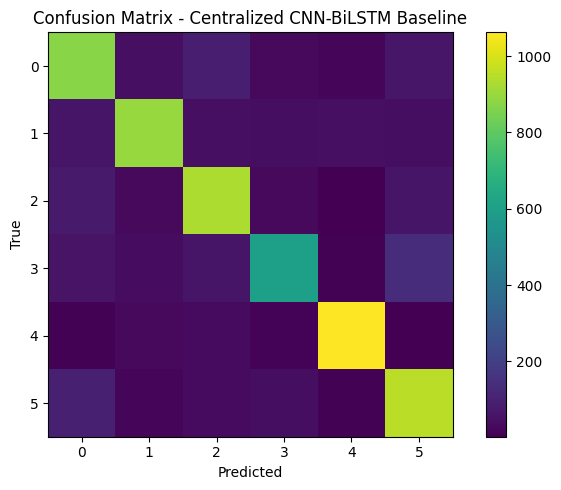


Running Local-only client baseline...
\n======================================================================
Local-only Client 1
accuracy            : 0.4762
balanced_accuracy   : 0.4787
precision_macro     : 0.4769
recall_macro        : 0.4787
f1_macro            : 0.4667
mcc                 : 0.3757
\nClassification report:
              precision    recall  f1-score   support

           0       0.36      0.42      0.39      1133
           1       0.57      0.47      0.51      1140
           2       0.43      0.36      0.39      1135
           3       0.38      0.56      0.45       903
           4       0.64      0.80      0.71      1153
           5       0.48      0.27      0.34      1151

    accuracy                           0.48      6615
   macro avg       0.48      0.48      0.47      6615
weighted avg       0.48      0.48      0.47      6615



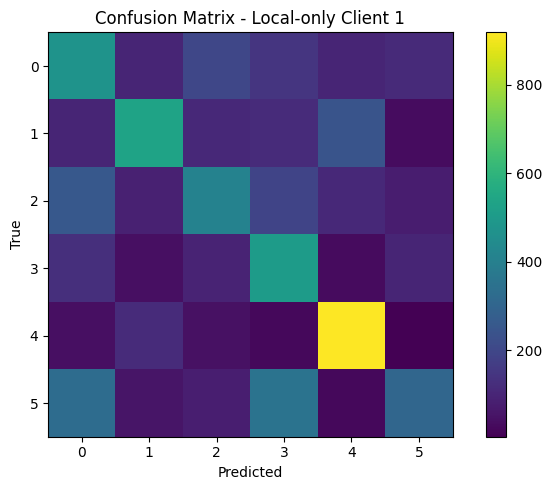

\n======================================================================
Local-only Client 2
accuracy            : 0.4789
balanced_accuracy   : 0.4753
precision_macro     : 0.4705
recall_macro        : 0.4753
f1_macro            : 0.4529
mcc                 : 0.3797
\nClassification report:
              precision    recall  f1-score   support

           0       0.43      0.13      0.19      1133
           1       0.51      0.52      0.51      1140
           2       0.38      0.55      0.45      1135
           3       0.39      0.40      0.40       903
           4       0.61      0.83      0.70      1153
           5       0.50      0.43      0.46      1151

    accuracy                           0.48      6615
   macro avg       0.47      0.48      0.45      6615
weighted avg       0.47      0.48      0.46      6615



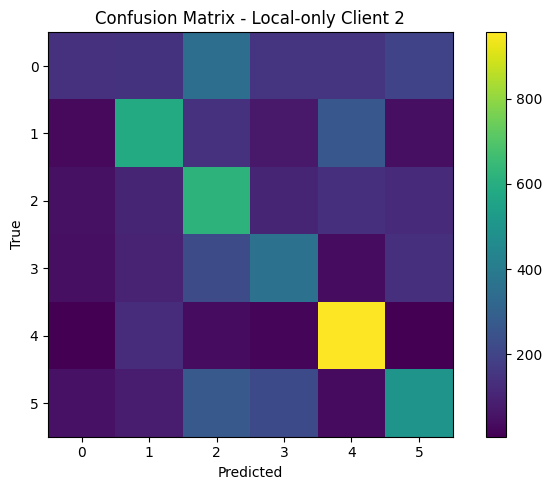

\n======================================================================
Local-only Client 3
accuracy            : 0.4818
balanced_accuracy   : 0.4844
precision_macro     : 0.4774
recall_macro        : 0.4844
f1_macro            : 0.4632
mcc                 : 0.3839
\nClassification report:
              precision    recall  f1-score   support

           0       0.46      0.19      0.27      1133
           1       0.49      0.56      0.52      1140
           2       0.46      0.29      0.35      1135
           3       0.40      0.59      0.47       903
           4       0.66      0.79      0.72      1153
           5       0.40      0.49      0.44      1151

    accuracy                           0.48      6615
   macro avg       0.48      0.48      0.46      6615
weighted avg       0.48      0.48      0.46      6615



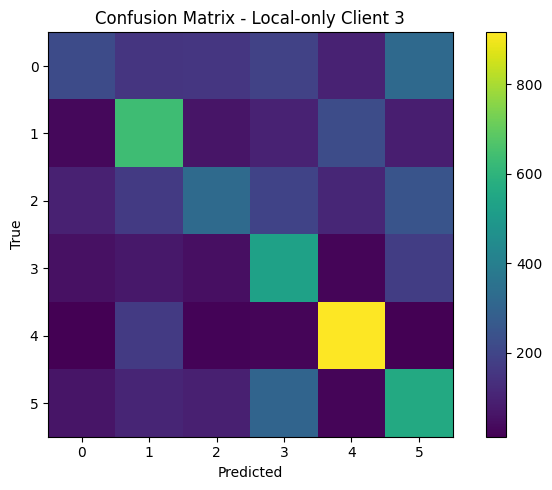

\n======================================================================
Local-only Client 4
accuracy            : 0.4089
balanced_accuracy   : 0.4172
precision_macro     : 0.4088
recall_macro        : 0.4172
f1_macro            : 0.3757
mcc                 : 0.3055
\nClassification report:
              precision    recall  f1-score   support

           0       0.36      0.21      0.26      1133
           1       0.51      0.33      0.40      1140
           2       0.39      0.11      0.17      1135
           3       0.31      0.68      0.43       903
           4       0.54      0.84      0.66      1153
           5       0.34      0.34      0.34      1151

    accuracy                           0.41      6615
   macro avg       0.41      0.42      0.38      6615
weighted avg       0.41      0.41      0.37      6615



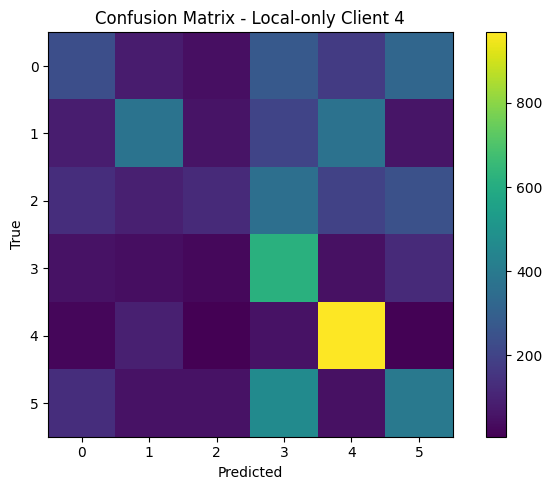


Running comparative FL method: FedAvg
  FedAvg round 1/5
  FedAvg round 2/5
  FedAvg round 3/5
  FedAvg round 4/5
  FedAvg round 5/5
\n======================================================================
FedAvg
accuracy            : 0.4033
balanced_accuracy   : 0.4073
precision_macro     : 0.3877
recall_macro        : 0.4073
f1_macro            : 0.3739
mcc                 : 0.2927
\nClassification report:
              precision    recall  f1-score   support

           0       0.32      0.14      0.20      1133
           1       0.48      0.32      0.38      1140
           2       0.33      0.20      0.25      1135
           3       0.33      0.55      0.41       903
           4       0.51      0.86      0.64      1153
           5       0.35      0.37      0.36      1151

    accuracy                           0.40      6615
   macro avg       0.39      0.41      0.37      6615
weighted avg       0.39      0.40      0.37      6615



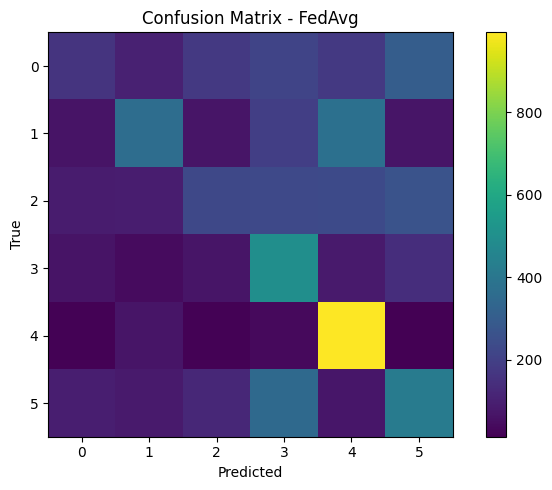


Running comparative FL method: DP-FedAvg
  DP-FedAvg round 1/5
  DP-FedAvg round 2/5
  DP-FedAvg round 3/5
  DP-FedAvg round 4/5
  DP-FedAvg round 5/5
\n======================================================================
DP-FedAvg
accuracy            : 0.4018
balanced_accuracy   : 0.4034
precision_macro     : 0.3864
recall_macro        : 0.4034
f1_macro            : 0.3743
mcc                 : 0.2889
\nClassification report:
              precision    recall  f1-score   support

           0       0.34      0.12      0.18      1133
           1       0.43      0.37      0.40      1140
           2       0.37      0.27      0.31      1135
           3       0.33      0.48      0.39       903
           4       0.48      0.83      0.61      1153
           5       0.37      0.35      0.36      1151

    accuracy                           0.40      6615
   macro avg       0.39      0.40      0.37      6615
weighted avg       0.39      0.40      0.37      6615



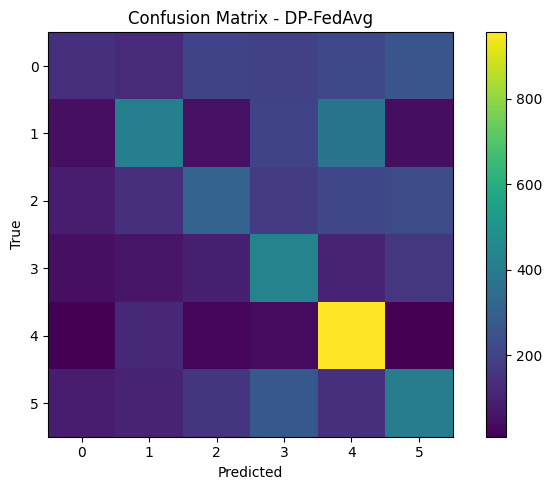


Running comparative FL method: FedProx-style FL
  FedProx-style FL round 1/5
  FedProx-style FL round 2/5
  FedProx-style FL round 3/5
  FedProx-style FL round 4/5
  FedProx-style FL round 5/5
\n======================================================================
FedProx-style FL
accuracy            : 0.4041
balanced_accuracy   : 0.4076
precision_macro     : 0.3869
recall_macro        : 0.4076
f1_macro            : 0.3724
mcc                 : 0.2937
\nClassification report:
              precision    recall  f1-score   support

           0       0.32      0.16      0.21      1133
           1       0.40      0.31      0.35      1140
           2       0.39      0.18      0.24      1135
           3       0.33      0.54      0.41       903
           4       0.50      0.87      0.63      1153
           5       0.38      0.38      0.38      1151

    accuracy                           0.40      6615
   macro avg       0.39      0.41      0.37      6615
weighted avg       0.39      

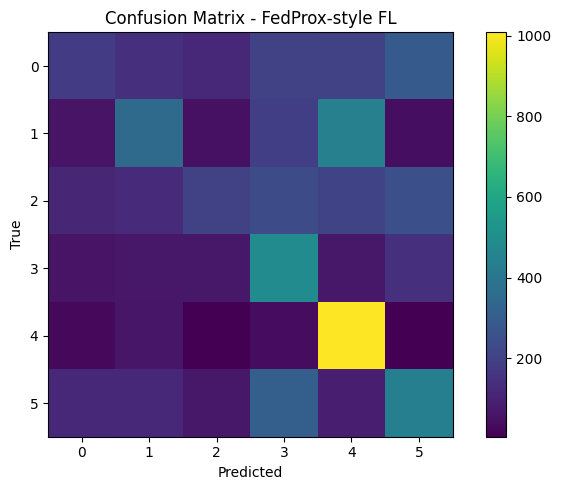

,method,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,mcc,notes
0,Proposed PP-HFL Global Model,0.893424,0.890886,0.893215,0.890886,0.891604,0.872050,Real-time + HFL + clipping + Gaussian noise + ...
1,Proposed PP-HFL Personalized Model,0.927286,0.925184,0.926595,0.925184,0.925587,0.912737,Global PP-HFL model followed by personalizatio...
2,Centralized CNN-BiLSTM,0.803930,0.798817,0.805117,0.798817,0.800411,0.764674,All data used centrally; no FL privacy
3,Local-only Learning,0.461451,0.463917,0.458399,0.463917,0.439600,0.361206,Each hospital trains independently; no aggrega...
4,FedAvg,0.403326,0.407269,0.387651,0.407269,0.373884,0.292692,Standard federated averaging baseline
5,DP-FedAvg,0.401814,0.403386,0.386391,0.403386,0.374343,0.288949,"FedAvg with clipping, Gaussian noise and secur..."
6,FedProx-style FL,0.404082,0.407646,0.386907,0.407646,0.372409,0.293730,Heterogeneous FL baseline with proximal-style ...


Saved comparative experiment summary to /kaggle/working/comparative_experiments_summary.csv


In [10]:
# ============================================================
# Comparative experiments against representative methods
# ============================================================

RUN_COMPARATIVE_EXPERIMENTS = True
COMPARISON_ROUNDS = 5
COMPARISON_LOCAL_EPOCHS = 2
COMPARISON_STREAM_CHUNK = 2048
COMPARISON_BATCH_SIZE = 32

comparison_rows = []

# Add current/proposed results already produced by the main PP-HFL pipeline.
if "final_results" in globals():
    comparison_rows.append(
        make_results_row(
            "Proposed PP-HFL Global Model",
            final_results,
            "Real-time + HFL + clipping + Gaussian noise + secure aggregation"
        )
    )

if "personalized_results" in globals():
    comparison_rows.append(
        make_results_row(
            "Proposed PP-HFL Personalized Model",
            personalized_results,
            "Global PP-HFL model followed by personalization/fine-tuning"
        )
    )


def train_centralized_baseline(max_epochs=10):
    """Centralized CNN-BiLSTM baseline using all available training data."""
    print("\nRunning Centralized CNN-BiLSTM baseline...")
    model = build_cnn_bilstm(input_shape=X_train_full.shape[1:], n_classes=y_train_full.shape[1], variant="medium")
    compile_model(model, lr=1e-3, label_smoothing=0.0)
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_train_full, y_train_full,
        test_size=0.15,
        random_state=SEED,
        stratify=np.argmax(y_train_full, axis=1)
    )
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True, mode="max"),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    ]
    class_weight = compute_balanced_class_weight(y_tr)
    model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=max_epochs,
        batch_size=COMPARISON_BATCH_SIZE,
        callbacks=callbacks,
        class_weight=class_weight,
        verbose=1
    )
    return evaluate_model(model, X_global_test, y_global_test, title="Centralized CNN-BiLSTM Baseline", plot_roc=False)


def train_local_only_baseline(max_epochs=6):
    """Local-only baseline: train one model per client and average their metrics."""
    print("\nRunning Local-only client baseline...")
    client_metric_rows = []
    for cid, (cx, cy) in enumerate(client_datasets):
        model = build_cnn_bilstm(input_shape=cx.shape[1:], n_classes=cy.shape[1], variant="small")
        compile_model(model, lr=1e-3, label_smoothing=0.0)
        X_tr, X_va, y_tr, y_va = safe_train_val_split(cx, cy, test_size=0.20, seed=SEED+cid)
        model.fit(
            X_tr, y_tr,
            validation_data=(X_va, y_va),
            epochs=max_epochs,
            batch_size=COMPARISON_BATCH_SIZE,
            callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True, mode="max")],
            class_weight=compute_balanced_class_weight(y_tr),
            verbose=0
        )
        metrics = evaluate_model(model, X_global_test, y_global_test, title=f"Local-only Client {cid+1}", plot_roc=False)
        client_metric_rows.append(metrics)
    avg = pd.DataFrame(client_metric_rows).mean(numeric_only=True).to_dict()
    return avg


def run_federated_baseline(method_name="FedAvg", rounds=5, local_epochs=2, use_dp=False, use_fedprox=False):
    """Run lightweight FL comparison with optional DP and FedProx-style damping."""
    print(f"\nRunning comparative FL method: {method_name}")
    model = build_cnn_bilstm(input_shape=X_train_full.shape[1:], n_classes=y_train_full.shape[1], variant="small")
    compile_model(model, lr=1e-3, label_smoothing=0.0)
    global_weights = model.get_weights()
    stream_positions = [0 for _ in range(NUM_CLIENTS)]

    for rnd in range(1, rounds + 1):
        updates, counts = [], []
        print(f"  {method_name} round {rnd}/{rounds}")
        for cid, (cx, cy) in enumerate(client_datasets):
            X_stream, y_stream, new_ptr, cx_new, cy_new = get_next_stream_window(
                cx, cy, stream_positions[cid], COMPARISON_STREAM_CHUNK
            )
            client_datasets[cid] = (cx_new, cy_new)
            stream_positions[cid] = new_ptr
            if len(X_stream) < 40:
                continue

            X_local, X_val, y_local, y_val = safe_train_val_split(
                X_stream, y_stream, test_size=0.15, seed=SEED+rnd+cid
            )
            local_model = clone_compiled_model(model, lr=CLIENT_CONFIGS[cid]["lr"])
            old_weights = local_model.get_weights()
            local_model.fit(
                X_local, y_local,
                validation_data=(X_val, y_val),
                epochs=local_epochs,
                batch_size=COMPARISON_BATCH_SIZE,
                callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True, mode="max")],
                class_weight=compute_balanced_class_weight(y_local),
                verbose=0
            )
            update = get_update(local_model.get_weights(), old_weights)

            if use_fedprox:
                update = fedprox_style_update(update, mu=0.05)

            if use_dp:
                update, _, _ = clip_weights_update(update, clip_norm=CLIP_NORM)
                update = add_gaussian_noise(update, noise_multiplier=NOISE_MULTIPLIER, clip_norm=CLIP_NORM)

            updates.append(update)
            counts.append(len(X_local))

        if updates:
            if use_dp:
                agg_update = secure_aggregate_simulated(updates, counts)
            else:
                agg_update = weighted_average_updates(updates, counts)
            global_weights = apply_update(global_weights, agg_update)
            model.set_weights(global_weights)

    return evaluate_model(model, X_global_test, y_global_test, title=method_name, plot_roc=False)


if RUN_COMPARATIVE_EXPERIMENTS:
    centralized_metrics = train_centralized_baseline(max_epochs=10)
    comparison_rows.append(make_results_row("Centralized CNN-BiLSTM", centralized_metrics, "All data used centrally; no FL privacy"))

    local_metrics = train_local_only_baseline(max_epochs=6)
    comparison_rows.append(make_results_row("Local-only Learning", local_metrics, "Each hospital trains independently; no aggregation"))

    fedavg_metrics = run_federated_baseline("FedAvg", rounds=COMPARISON_ROUNDS, local_epochs=COMPARISON_LOCAL_EPOCHS, use_dp=False, use_fedprox=False)
    comparison_rows.append(make_results_row("FedAvg", fedavg_metrics, "Standard federated averaging baseline"))

    dp_fedavg_metrics = run_federated_baseline("DP-FedAvg", rounds=COMPARISON_ROUNDS, local_epochs=COMPARISON_LOCAL_EPOCHS, use_dp=True, use_fedprox=False)
    comparison_rows.append(make_results_row("DP-FedAvg", dp_fedavg_metrics, "FedAvg with clipping, Gaussian noise and secure aggregation simulation"))

    fedprox_metrics = run_federated_baseline("FedProx-style FL", rounds=COMPARISON_ROUNDS, local_epochs=COMPARISON_LOCAL_EPOCHS, use_dp=False, use_fedprox=True)
    comparison_rows.append(make_results_row("FedProx-style FL", fedprox_metrics, "Heterogeneous FL baseline with proximal-style update damping"))

comparison_df = pd.DataFrame(comparison_rows)
metric_cols = ["method", "accuracy", "balanced_accuracy", "precision_macro", "recall_macro", "f1_macro", "mcc", "notes"]
comparison_df = comparison_df[[c for c in metric_cols if c in comparison_df.columns]]
display(comparison_df)
comparison_df.to_csv("/kaggle/working/comparative_experiments_summary.csv", index=False)
print("Saved comparative experiment summary to /kaggle/working/comparative_experiments_summary.csv")

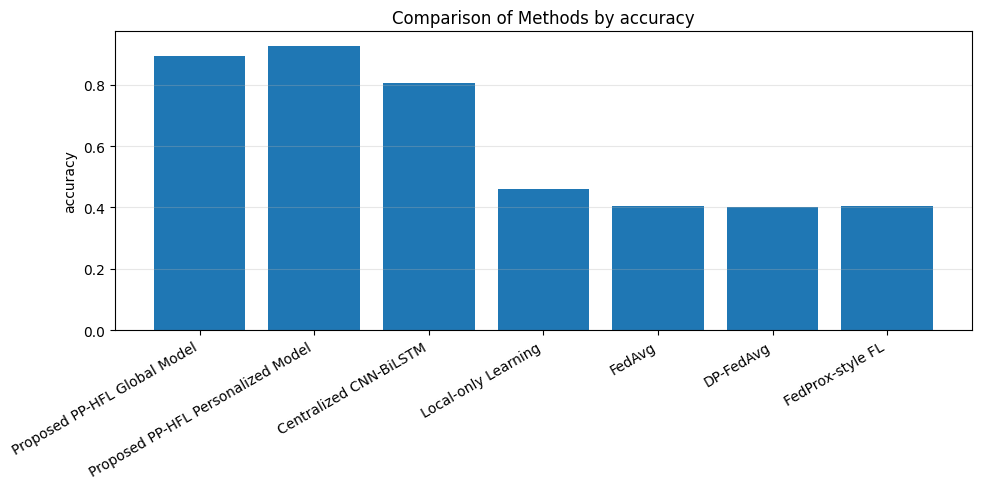

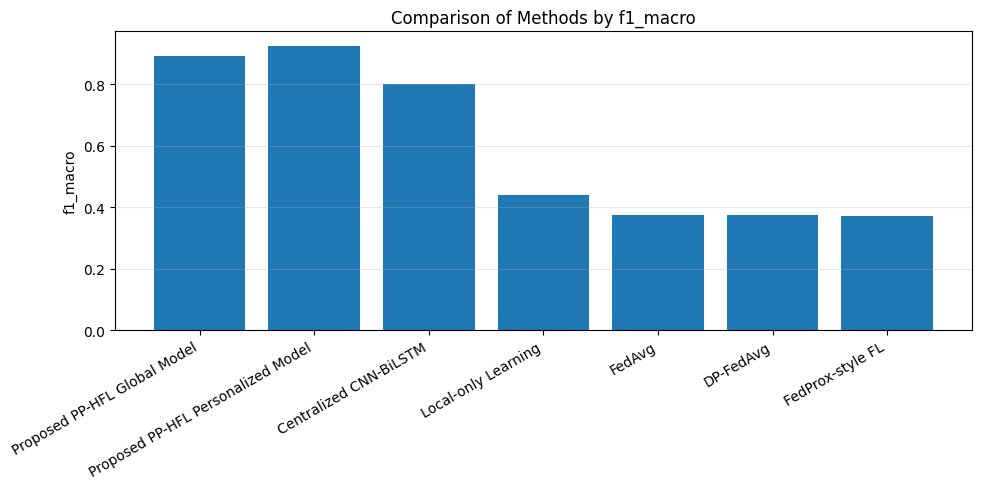

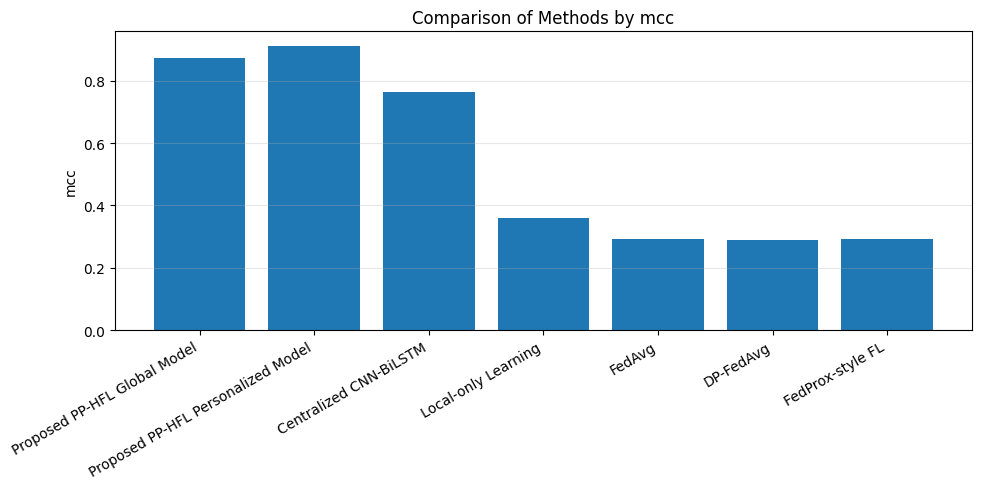

Best method based on accuracy:


,method,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,mcc,notes
1,Proposed PP-HFL Personalized Model,0.927286,0.925184,0.926595,0.925184,0.925587,0.912737,Global PP-HFL model followed by personalizatio...


In [11]:
# ============================================================
# Comparative experiment plots for dissertation/supervisor report
# ============================================================
if "comparison_df" in globals() and len(comparison_df) > 0:
    plot_df = comparison_df.copy()
    for metric in ["accuracy", "f1_macro", "mcc"]:
        if metric in plot_df.columns:
            plt.figure(figsize=(10, 5))
            plt.bar(plot_df["method"], plot_df[metric])
            plt.title(f"Comparison of Methods by {metric}")
            plt.ylabel(metric)
            plt.xticks(rotation=30, ha="right")
            plt.grid(axis="y", alpha=0.3)
            plt.tight_layout()
            plt.show()

    best_row = plot_df.sort_values("accuracy", ascending=False).head(1)
    print("Best method based on accuracy:")
    display(best_row)

## How to Explain These Experiments to the Supervisor

The comparative section is designed to show that the proposed method is not evaluated in isolation. It compares the proposed framework against common baseline methods:

- **Centralized CNN–BiLSTM:** useful as a reference, but it is not privacy-preserving because all data are combined centrally.
- **Local-only learning:** shows that hospitals training alone usually lose the benefit of collaborative learning.
- **FedAvg:** reproduces the standard federated learning baseline and previous-student style workflow.
- **DP-FedAvg:** adds privacy-preserving clipping and Gaussian noise.
- **FedProx-style FL:** represents heterogeneous FL by reducing client drift.
- **Proposed PP-HFL:** combines real-time streaming, heterogeneous clients, privacy preservation, secure aggregation simulation and optional personalization.

This supports the research contribution: the proposed framework builds upon the previous students' work and demonstrates performance under privacy-preserving and heterogeneous federated conditions.